In [26]:
import warnings

import astropy.units
import FunctionLib as FL
import inspect
from tqdm import tqdm
import astropy
import wave
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict
import re
import scipy

mpl.rcParams['font.family'] = 'serif'


warnings.filterwarnings("ignore")

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(os.path.expanduser(
    './DJAv4Catalog.pkl'))
print(DJAv4Catalog.sample_num())

DJAv4Catalog.to_dataframe()


459


,survey_id_subid,survey_id,prism_filepath,prism_redshift,grating_filepaths,grating_redshifts,determined_redshift,file_count,available_filters,properties
0,snh0pe-v4_4446_102,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.2259,{'g235m-f170lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g235m-f170lp': nan, 'g140m-f100lp': nan}",0.2259,3,"{g235m-f170lp, g140m-f100lp, prism-clear}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
1,snh0pe-v4_4446_143,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.6318,{'g235m-f170lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g235m-f170lp': 1.6309, 'g140m-f100lp': 1.6313}",1.6311,3,"{g235m-f170lp, g140m-f100lp, prism-clear}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
2,snh0pe-v4_4446_285,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,0.4446,{'g235m-f170lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",0.4462,3,"{g235m-f170lp, g140m-f100lp, prism-clear}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
3,snh0pe-v4_4446_29,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.7834,{'g235m-f170lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g235m-f170lp': 1.7796, 'g140m-f100lp': 1.7799}",1.77975,3,"{g235m-f170lp, g140m-f100lp, prism-clear}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
4,snh0pe-v4_4446_123,snh0pe-v4,/home/xingyaocai/DJAv4/snh0pe-v4/snh0pe-v4_pri...,1.7855,{'g235m-f170lp': '/home/xingyaocai/DJAv4/snh0p...,"{'g235m-f170lp': 1.7851, 'g140m-f100lp': 1.7855}",1.7855,3,"{g235m-f170lp, g140m-f100lp, prism-clear}","{'redshift_conflict': False, 'Sample_Flag': Fa..."
...,...,...,...,...,...,...,...,...,...,...
32564,ceers-ddt-v4_2750_1636,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,3.0592,{},{},3.0592,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32565,ceers-ddt-v4_2750_3213,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,4.8013,{},{},4.8013,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32566,ceers-ddt-v4_2750_340,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,0.9585,{},{},0.9585,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."
32567,ceers-ddt-v4_2750_21413,ceers-ddt-v4,/home/xingyaocai/DJAv4/ceers-ddt-v4/ceers-ddt-...,2.1402,{},{},2.1402,1,{prism-clear},"{'redshift_conflict': False, 'Sample_Flag': Fa..."


In [27]:
alpha=list()
alpha_err=list()
beta=list()
beta_err=list()
redshift=list()
survey_id_sub_id=list()

for id, catalog in tqdm(DJAv4Catalog.catalog_iterator()):
    if not catalog['properties']['Sample_Flag']:
        continue

    try:

        for filter, grating_path in catalog['grating_filepaths'].items():
            grating_filepath = os.path.expanduser('~/' + grating_path[16:])
            grating_spectrum=FL.Load_Spectrum_From_Fits(grating_filepath,catalog['determined_redshift'])


            if (grating_spectrum.dual_boundarys()[0]< 4763.0*astropy.units.AA)&(grating_spectrum.dual_boundarys()[1]> 6663.0*astropy.units.AA):
                #Halpha Measure
                grating_spectrum.set_boundarys(6563.0*astropy.units.AA-100.0*astropy.units.AA, 6563.0*astropy.units.AA+100.0*astropy.units.AA)

                if len(grating_spectrum.processing_flux.data)<10:
                    continue


                #error estimation
                restFrameWavelength=6563.0*astropy.units.AA
                grating_spectrum.set_boundarys(restFrameWavelength-75.0*astropy.units.AA, restFrameWavelength+75.0*astropy.units.AA)

                AlphaLineError, AlphaLineFlux=FL.calculate_err_at_given_wavelength(grating_spectrum, restFrameWavelength)

                #HBeta Measure
                grating_spectrum.set_boundarys(4863.0*astropy.units.AA-100.0*astropy.units.AA, 4863.0*astropy.units.AA+100.0*astropy.units.AA)
                if len(grating_spectrum.processing_flux.data)<10:
                    continue

                restFrameWavelength=4863.0*astropy.units.AA
                grating_spectrum.set_boundarys(restFrameWavelength-75.0*astropy.units.AA, restFrameWavelength+75.0*astropy.units.AA)
                BetaLineError, BetaLineFlux=FL.calculate_err_at_given_wavelength(grating_spectrum, restFrameWavelength)

                if (AlphaLineFlux>0)&(BetaLineFlux>0):
                    alpha.append(AlphaLineFlux)
                    alpha_err.append(AlphaLineError)
                    beta.append(BetaLineFlux)
                    beta_err.append(BetaLineError)
                    redshift.append(catalog['determined_redshift'])
                    survey_id_sub_id.append(catalog['id'])

                break

    except Exception as e:
        print(f"Error processing catalog {id}: {e}")


25089it [00:05, 8907.88it/s]

Error processing catalog rubies-uds23-v4_4233_181919: high <= 0


26125it [00:06, 2705.06it/s]

Error processing catalog rubies-uds23-v4_4233_150496: high <= 0


32569it [00:07, 4246.20it/s]


In [28]:
def err(alphaValve, alphaError, betaValve, betaError):
    err_ratio=alphaError**2/betaValve**2 + betaError**2*alphaValve**2/betaValve**4
    return np.sqrt(err_ratio)

alpha=np.array(alpha)
alpha_err=np.array(alpha_err)
beta=np.array(beta)
beta_err=np.array(beta_err)
error=np.array(err(alpha, alpha_err, beta, beta_err))
redshift=np.array(redshift)
survey_id_sub_id=np.array(survey_id_sub_id)

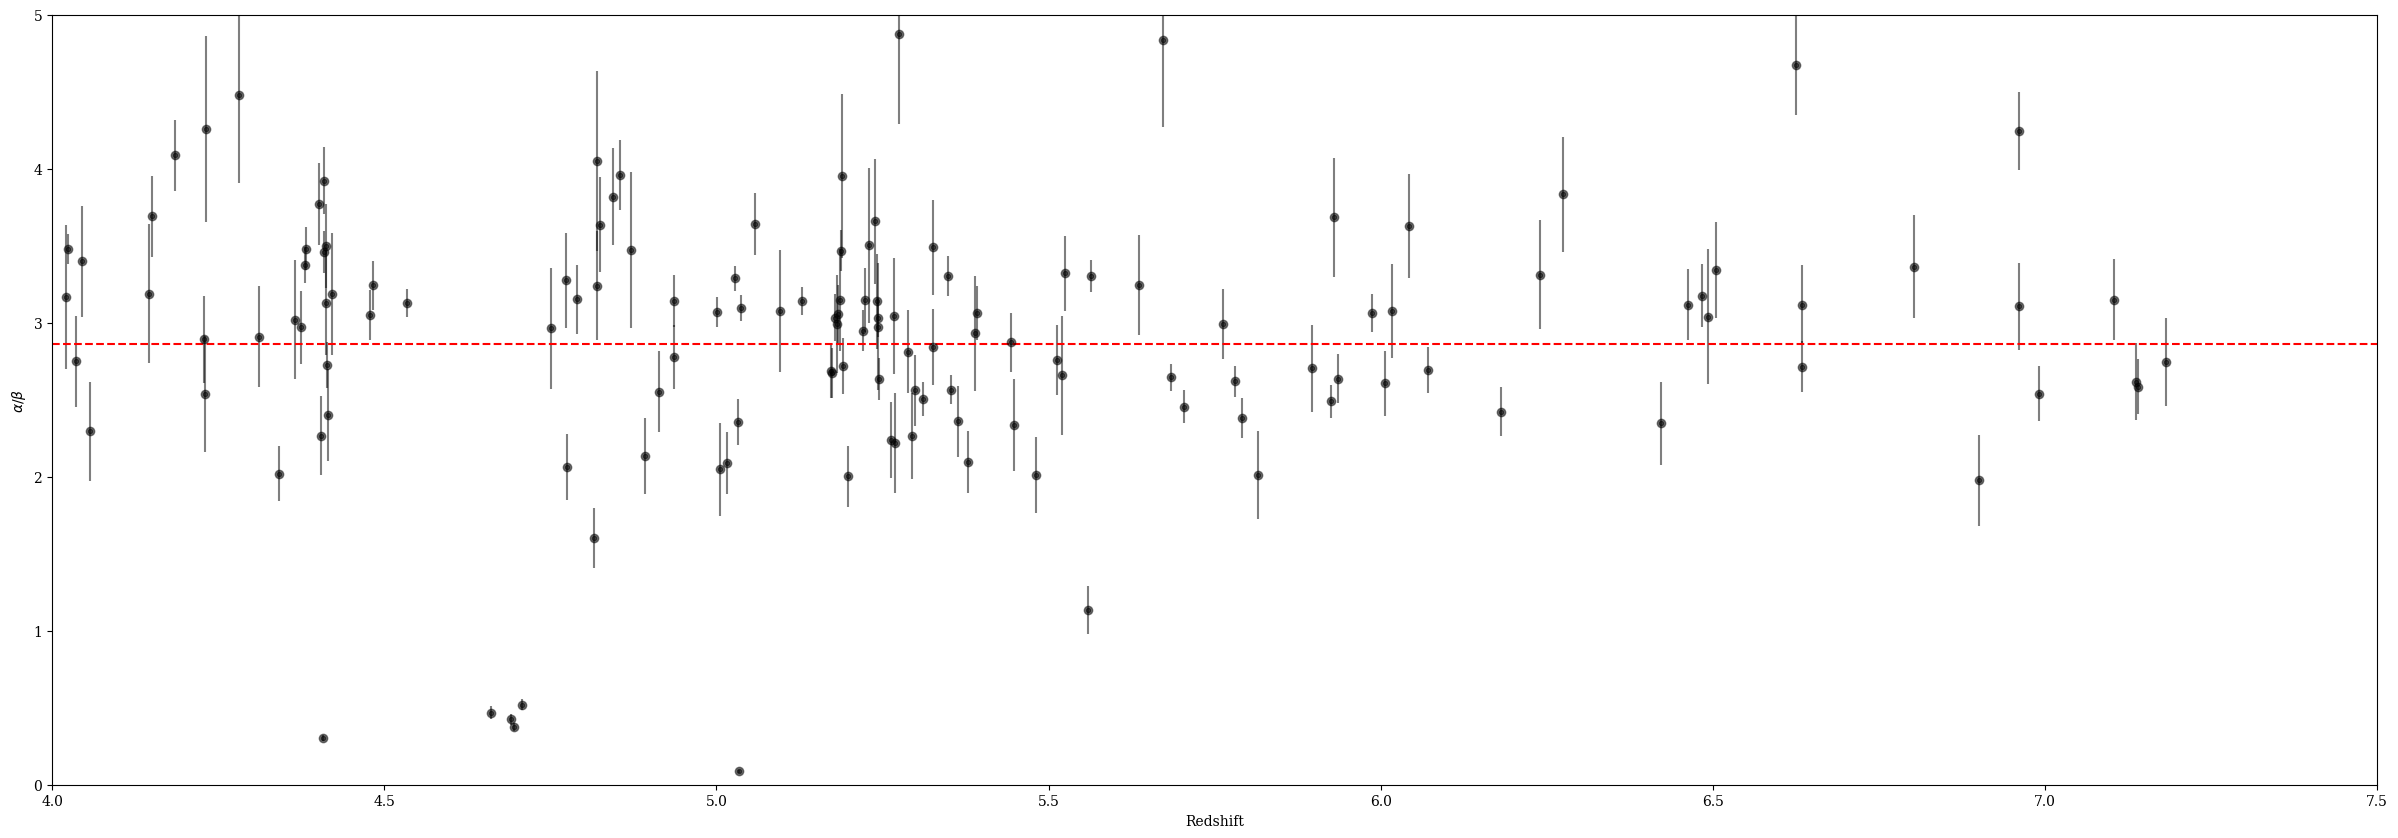

In [32]:
plt.figure(figsize=(30,10))
for i in range(len(alpha)):
    if err(alpha[i], alpha_err[i], beta[i], beta_err[i])/ (alpha[i]/beta[i])>0.15:
        continue
    if alpha[i]/beta[i]>5 or redshift[i]<4 or redshift[i]>7.5:
        continue
    plt.scatter(redshift[i], alpha[i]/beta[i], s=10, alpha=0.5,c='k')
    plt.errorbar(redshift[i], alpha[i]/beta[i], yerr=err(alpha[i], alpha_err[i], beta[i], beta_err[i]), fmt='o', alpha=0.5,c='k')
    #plt.text(redshift[i], alpha[i]/beta[i], survey_id_sub_id[i], fontsize=8, alpha=0.5)
plt.xlabel('Redshift')
plt.ylabel(r'$\alpha/\beta$')
plt.ylim(0,5)
plt.xlim(4,7.5)
plt.axhline(y=2.86, color='r', linestyle='--', label='Expected Ratio')


In [ ]:
ids=np.where((alpha/beta<2.5)&(alpha/beta>1.0)&(error/(alpha/beta)<0.1))
ids_name=survey_id_sub_id[ids]

In [ ]:
ids_name.shape

jades-gdn2-v4_1181_1560
4.026265016030352e-17
2.014039250913787e-17
1.9990995777284881


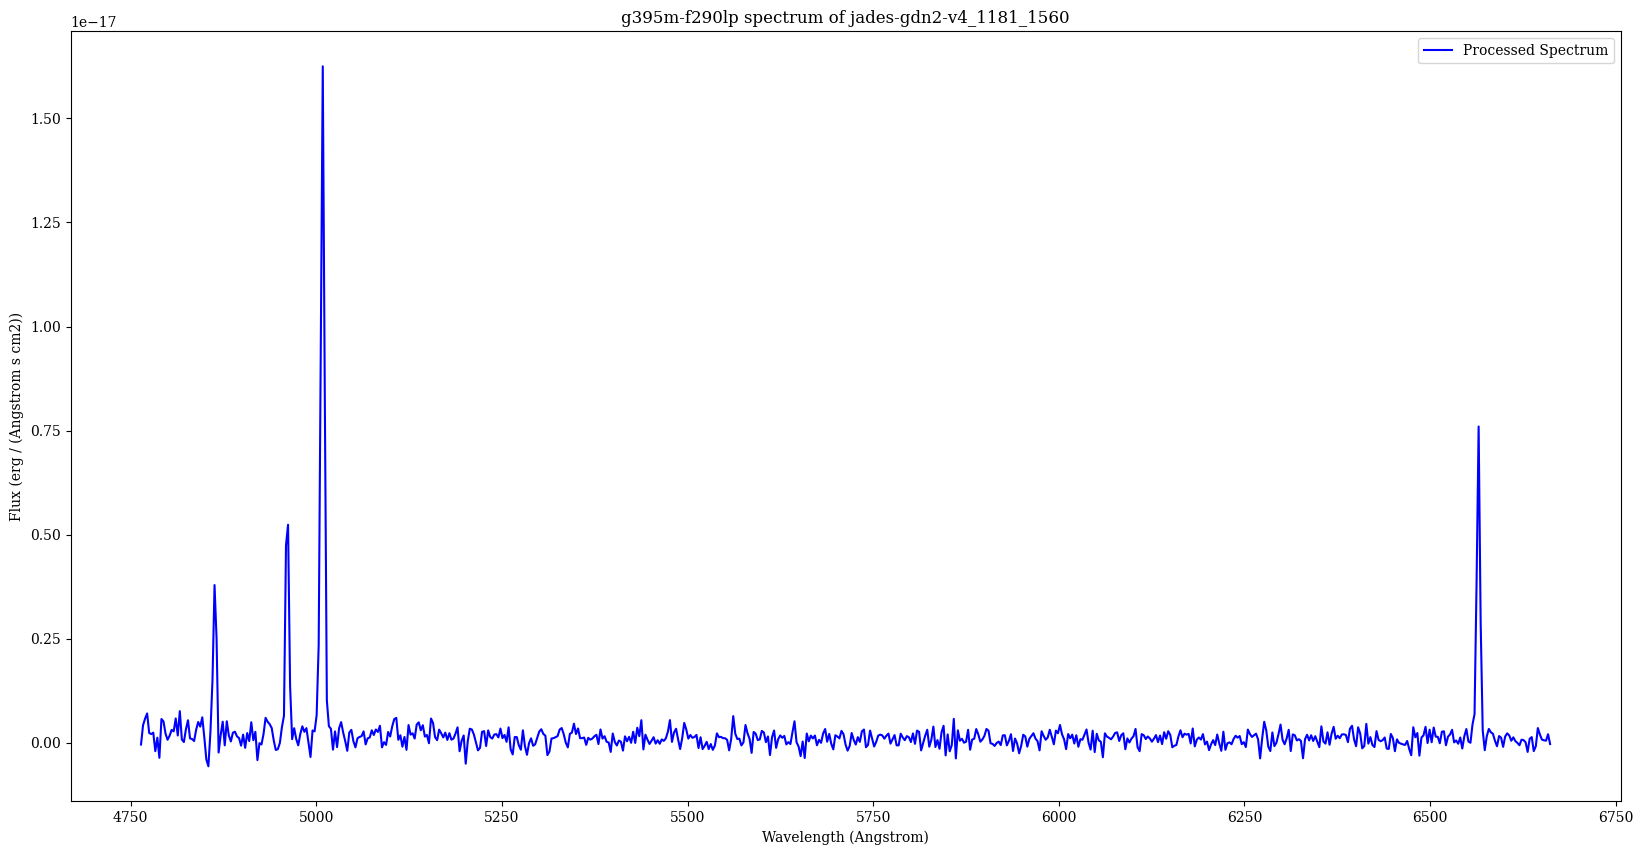

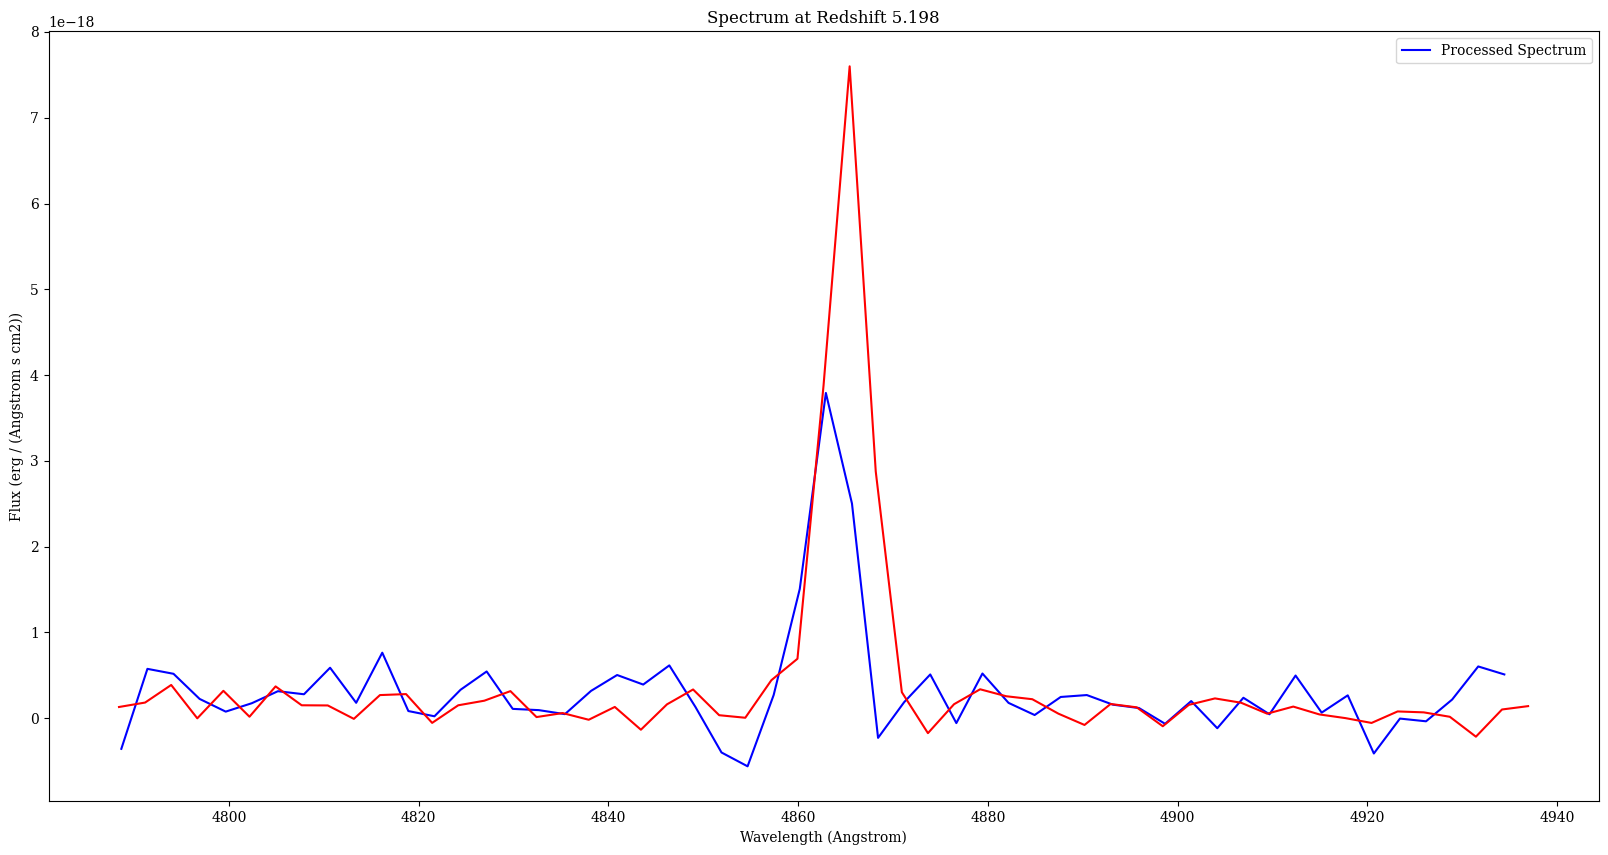

jades-gdn2-v4_1181_38493
1.953359978407849e-17
9.305205091558812e-18
2.0992121712393352


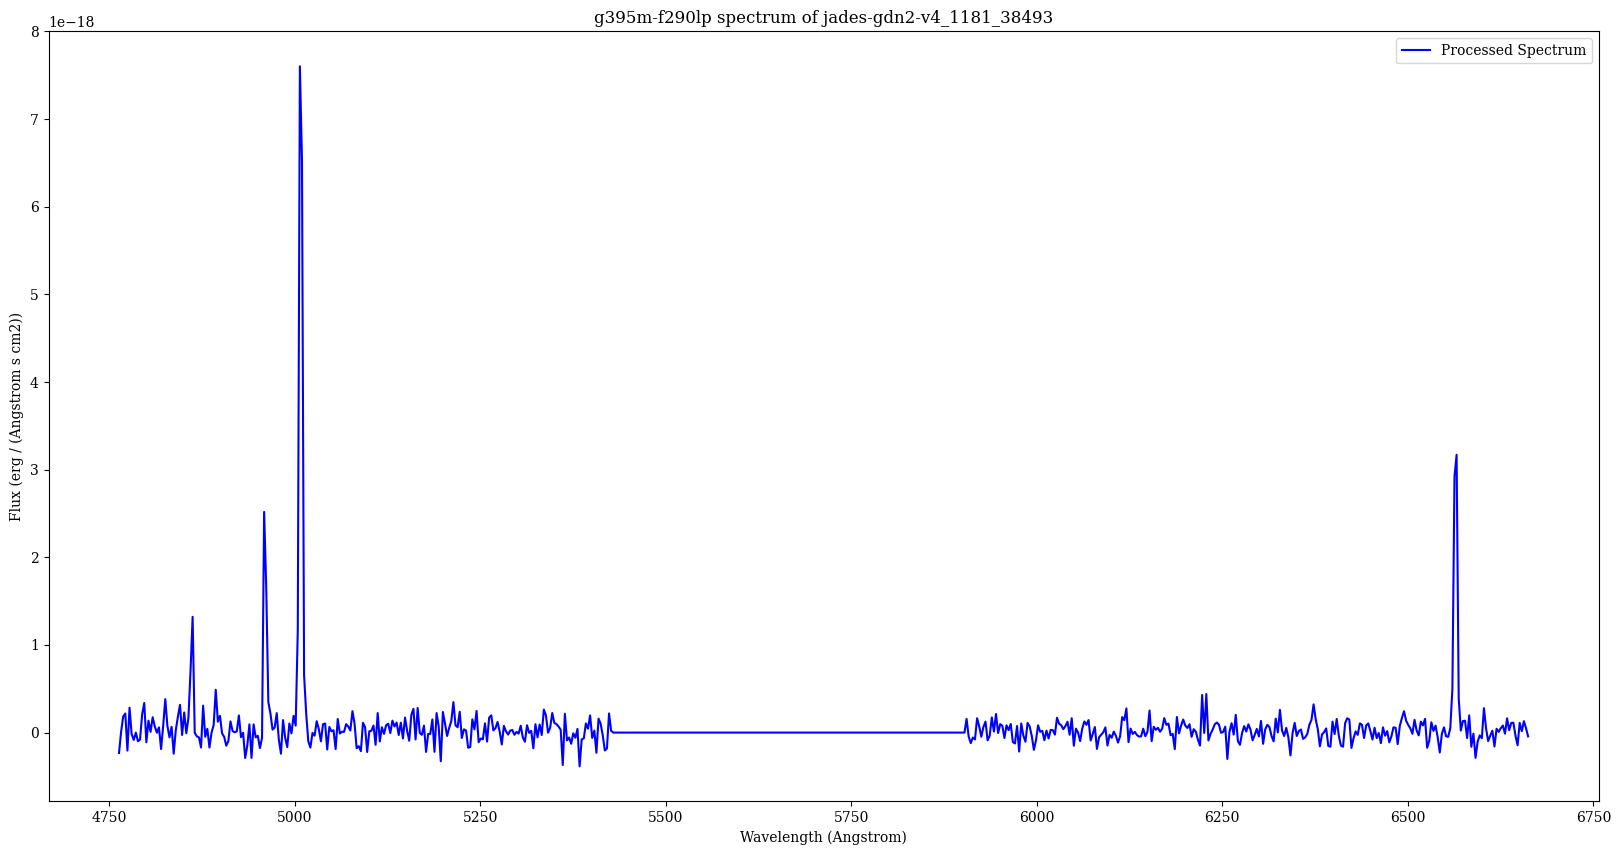

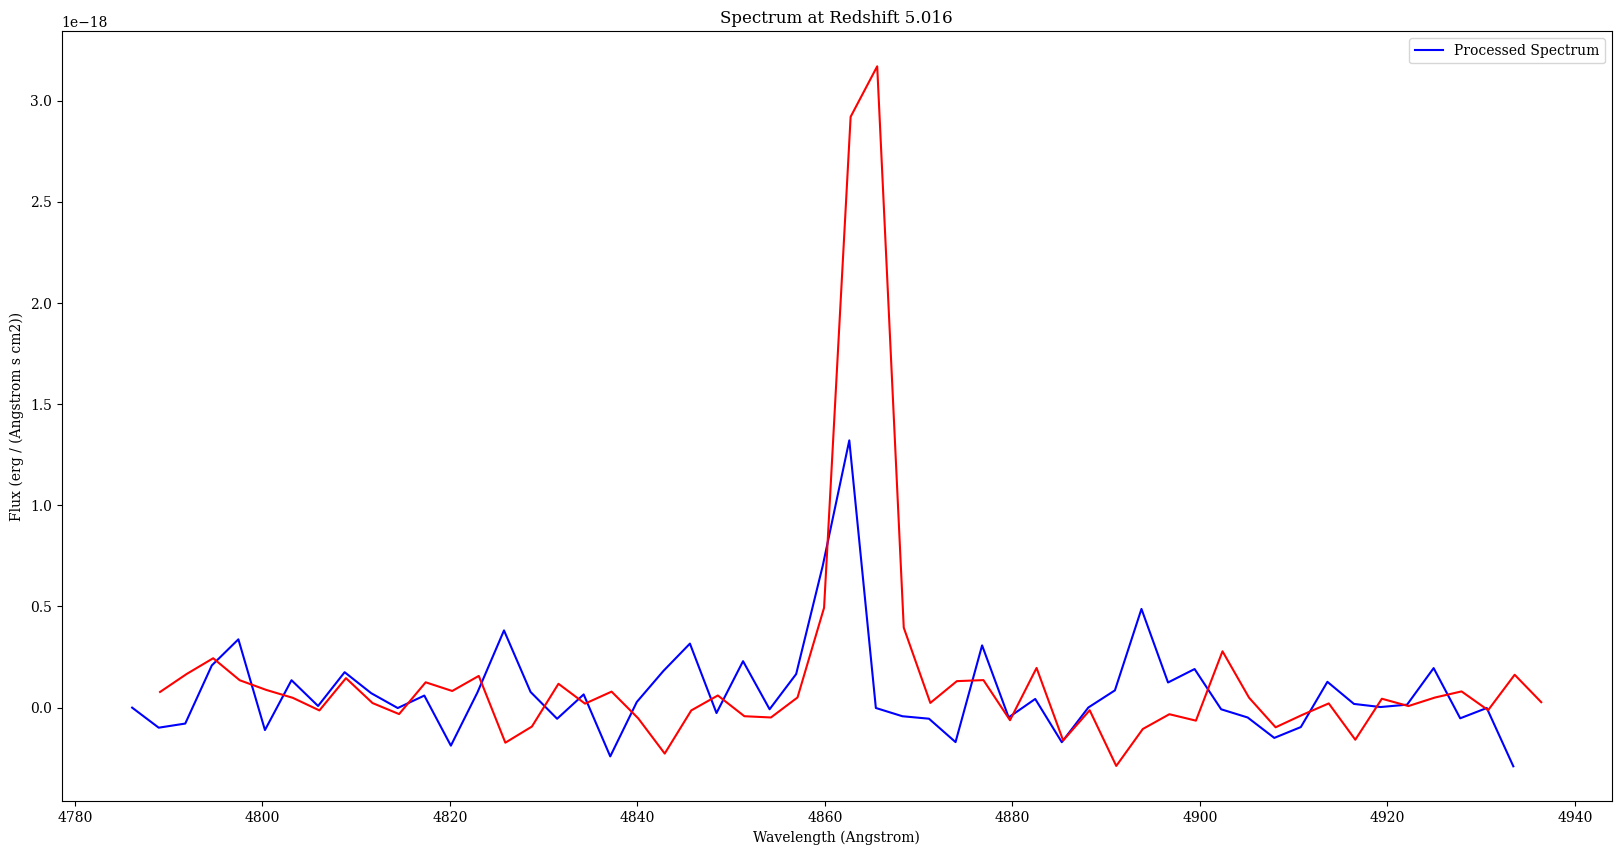

jades-gds02-v4_1286_189400
1.2572812316337587e-17
6.2019153644741505e-18
2.027246677430854


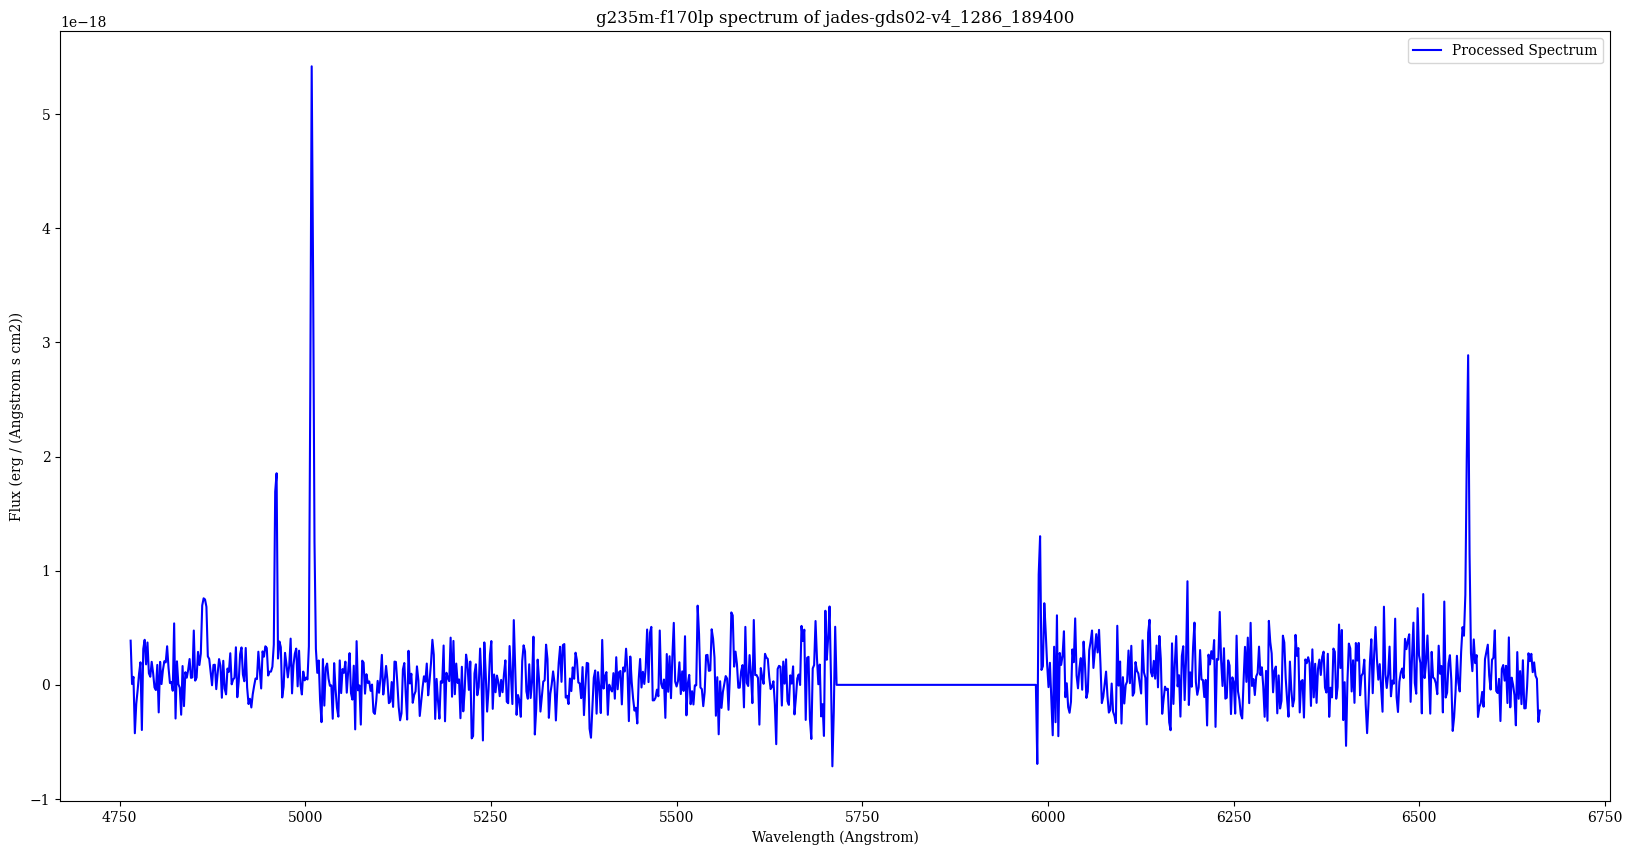

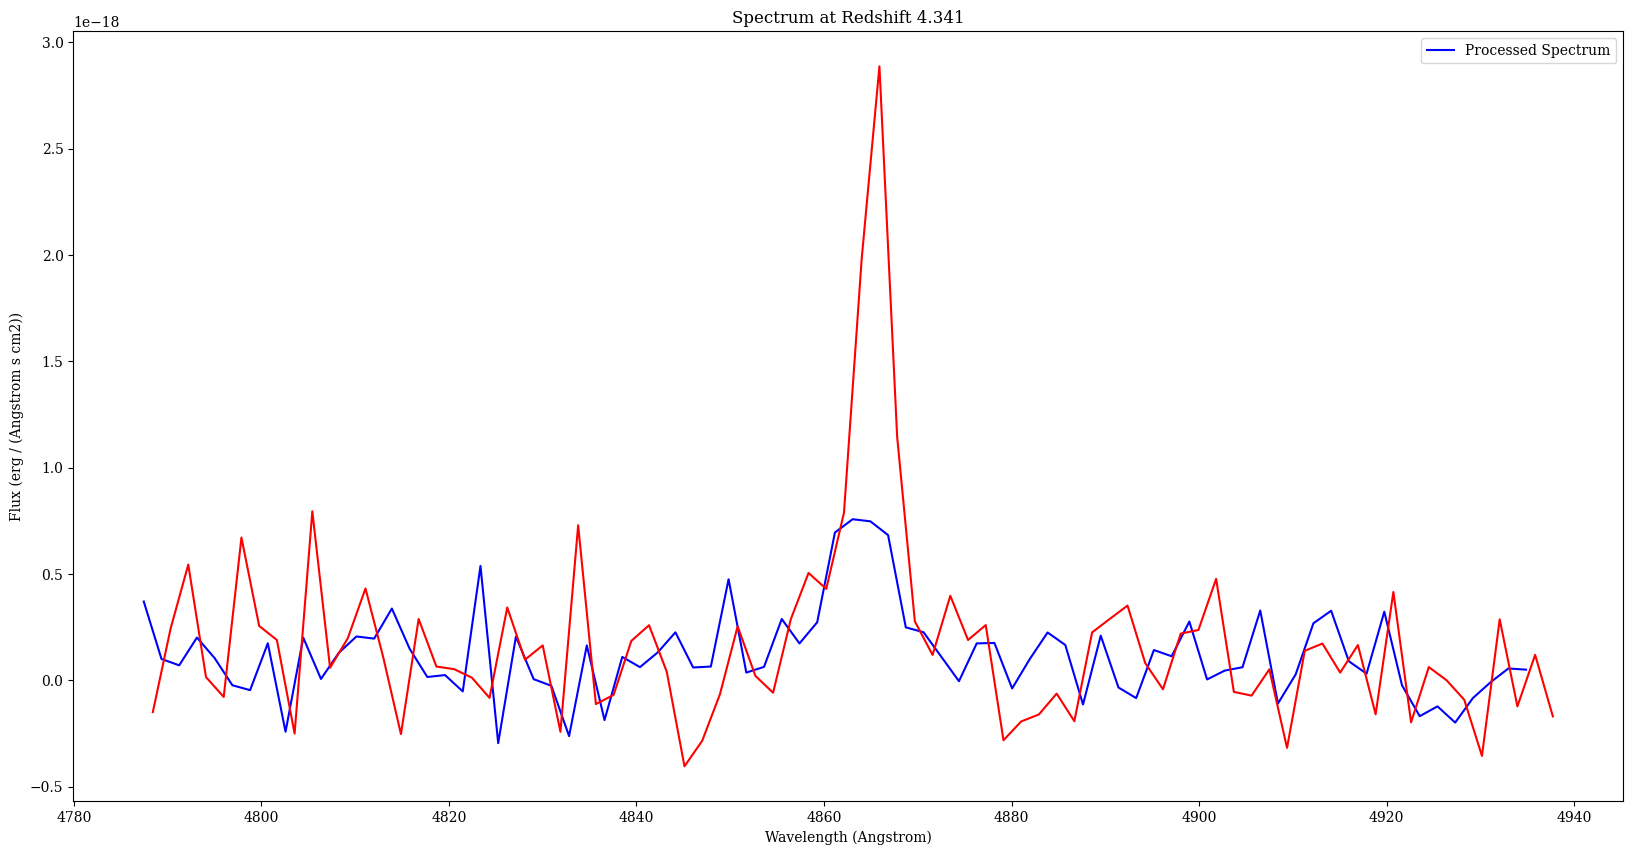

rubies-uds32-v4_4233_127560
5.660441405264146e-17
2.3882768872512906e-17
2.37009428658787


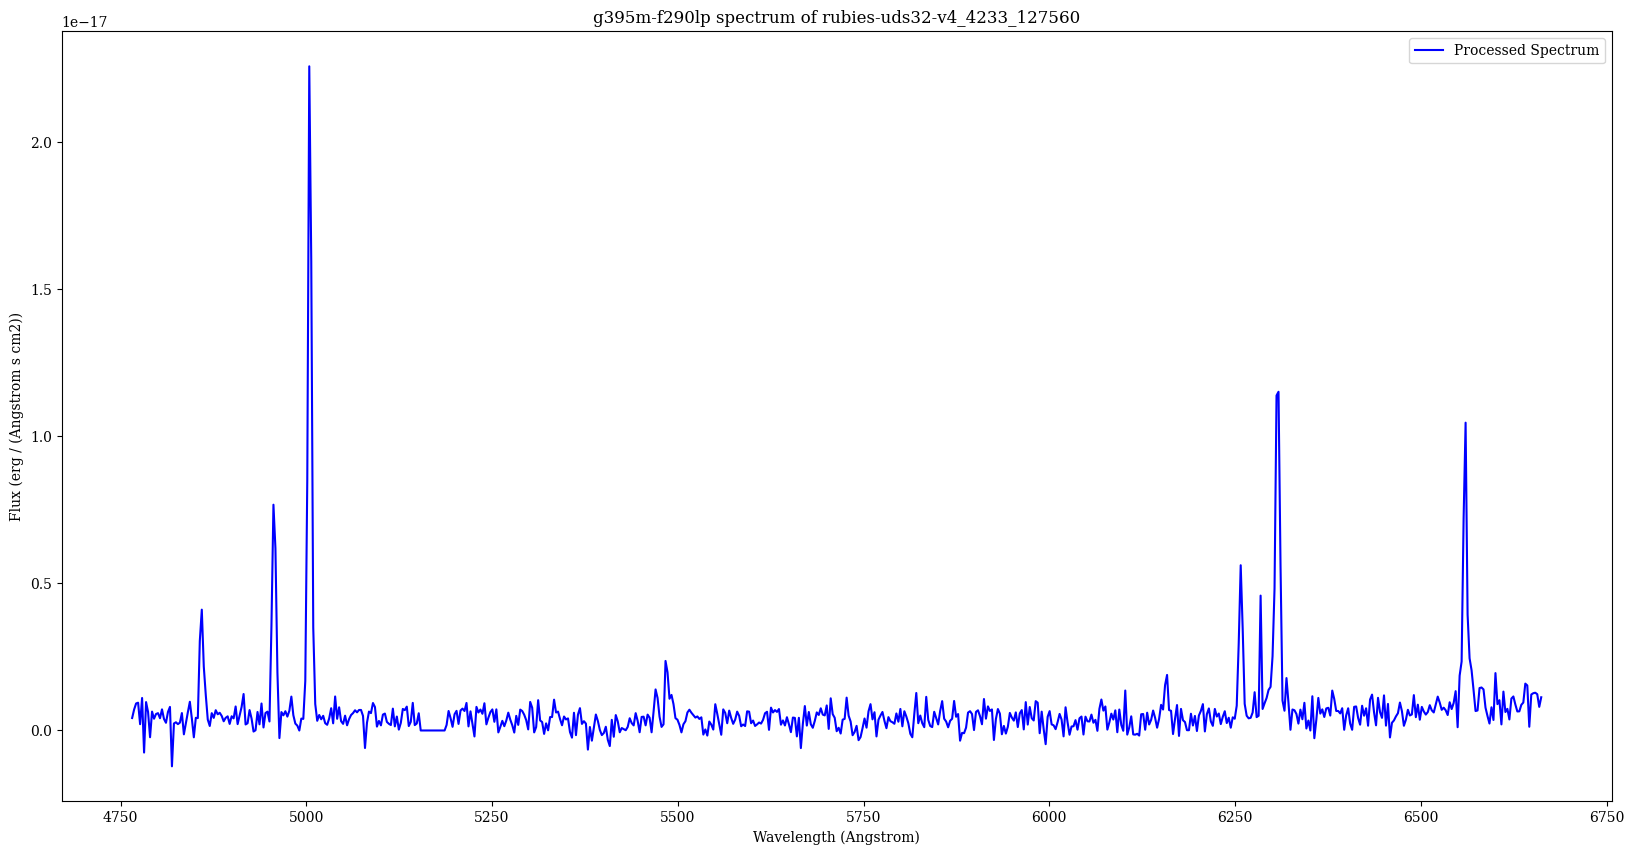

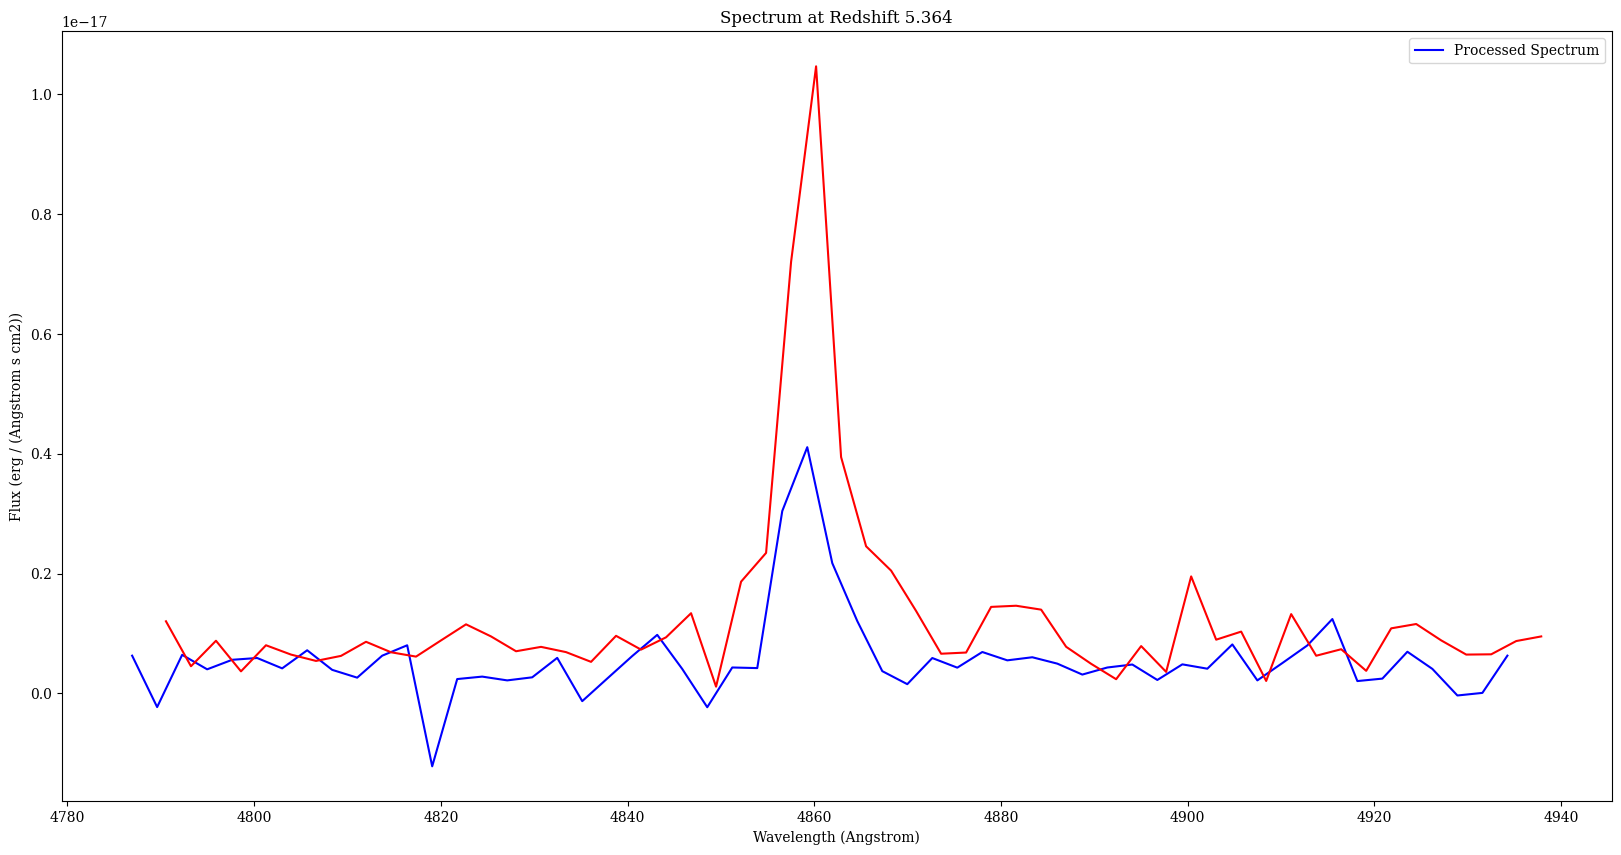

jades-gds10-v4_1287_63685
1.794839173951655e-17
7.517224397657543e-18
2.387635487522427


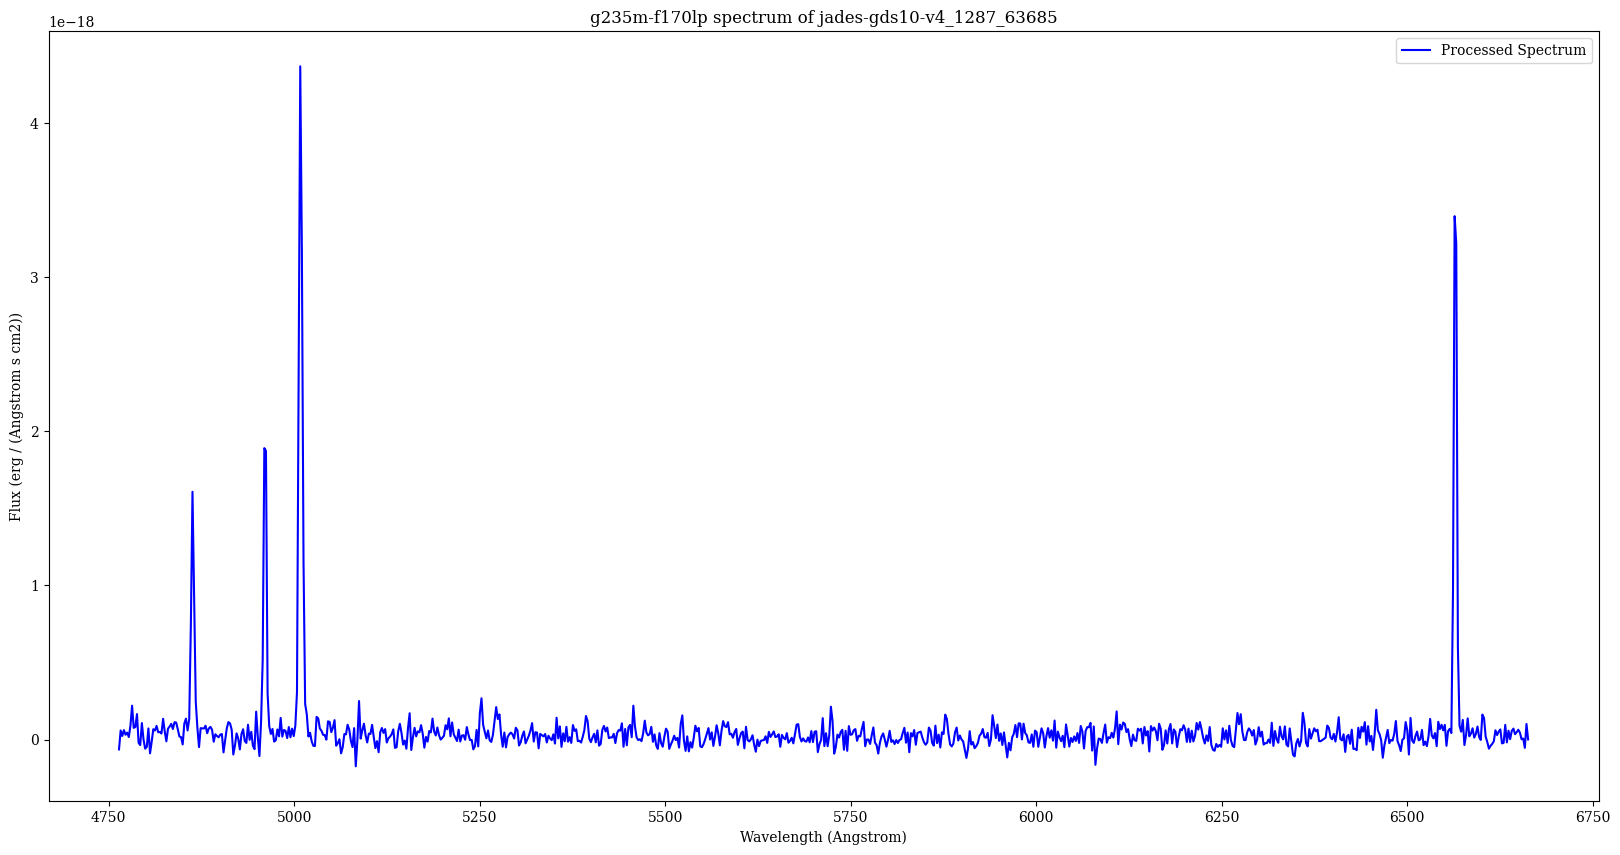

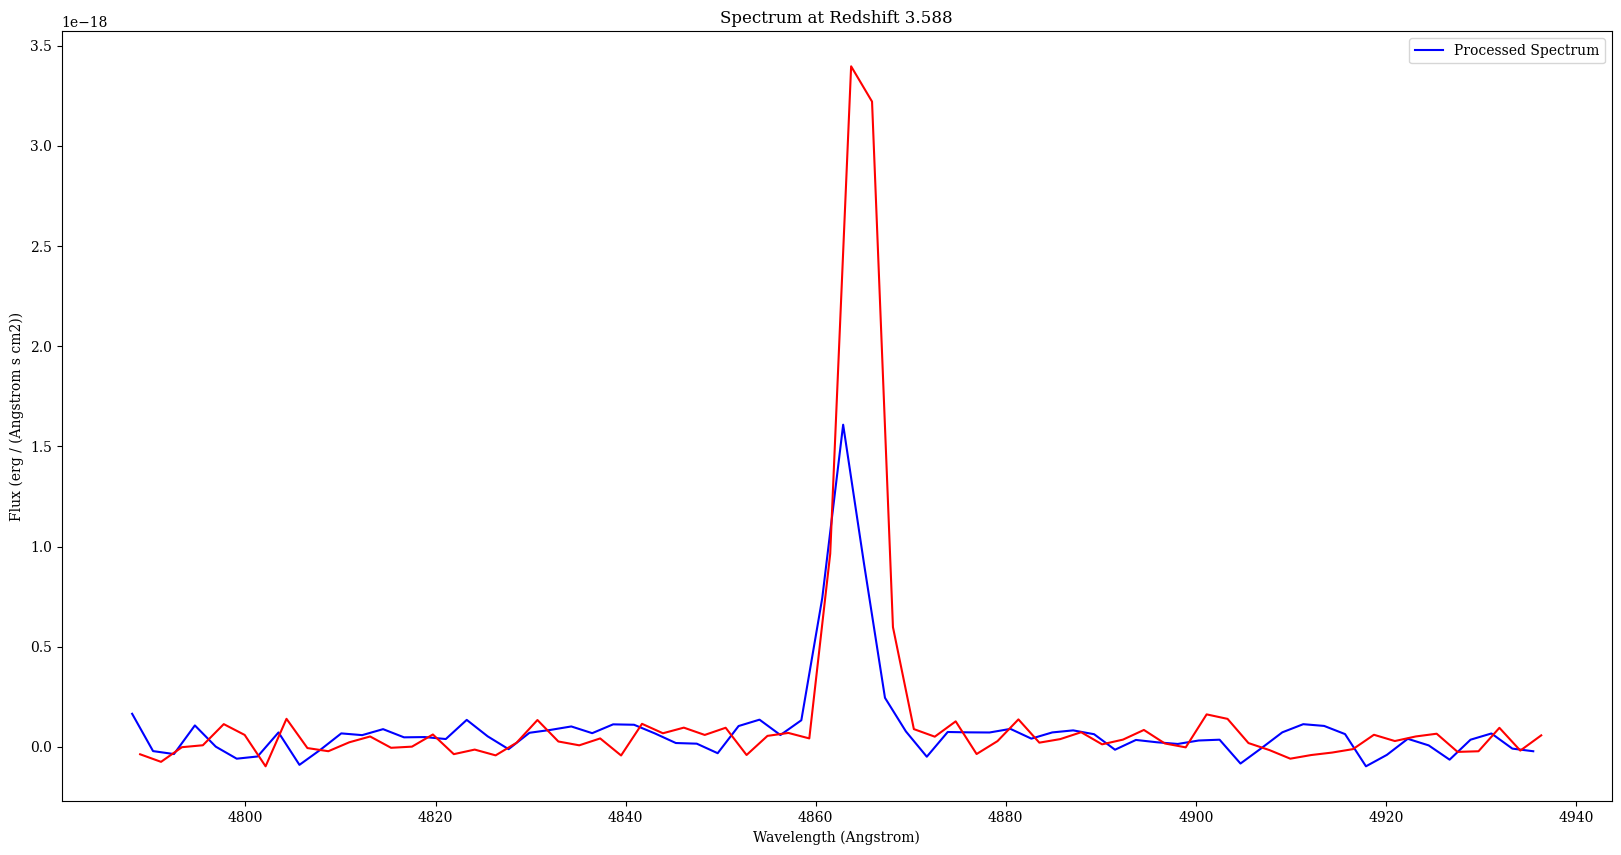

ceers-v4_1345_1691
1.8534220821783458e-17
8.046945163243788e-18
2.3032617279961887


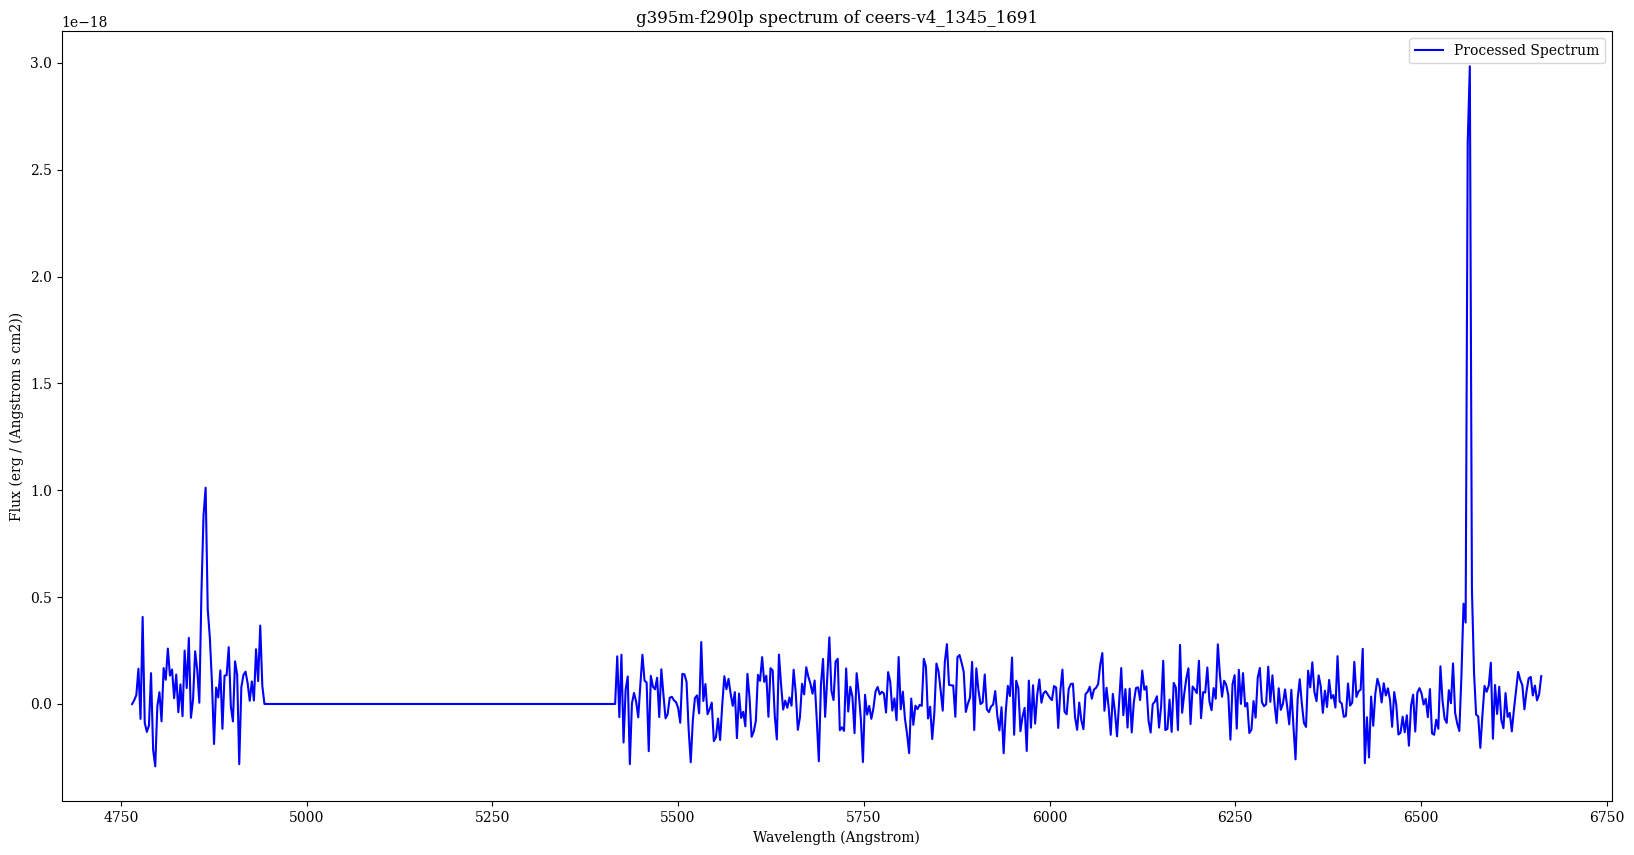

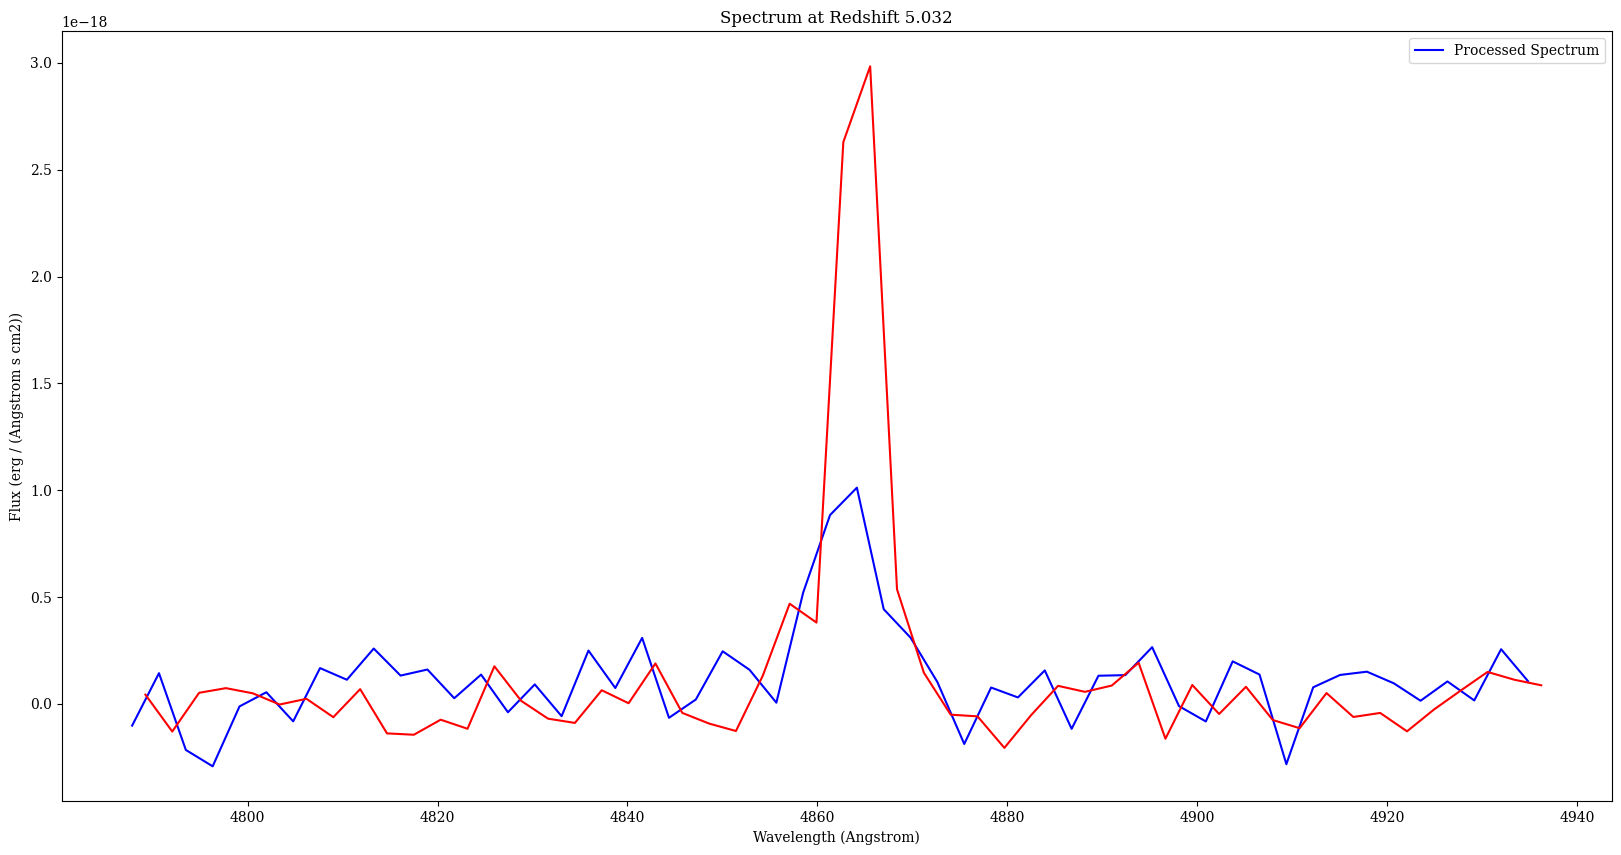

rubies-egs51-v4_4233_26883
5.148043811660582e-17
2.123760717475055e-17
2.4240225225472223


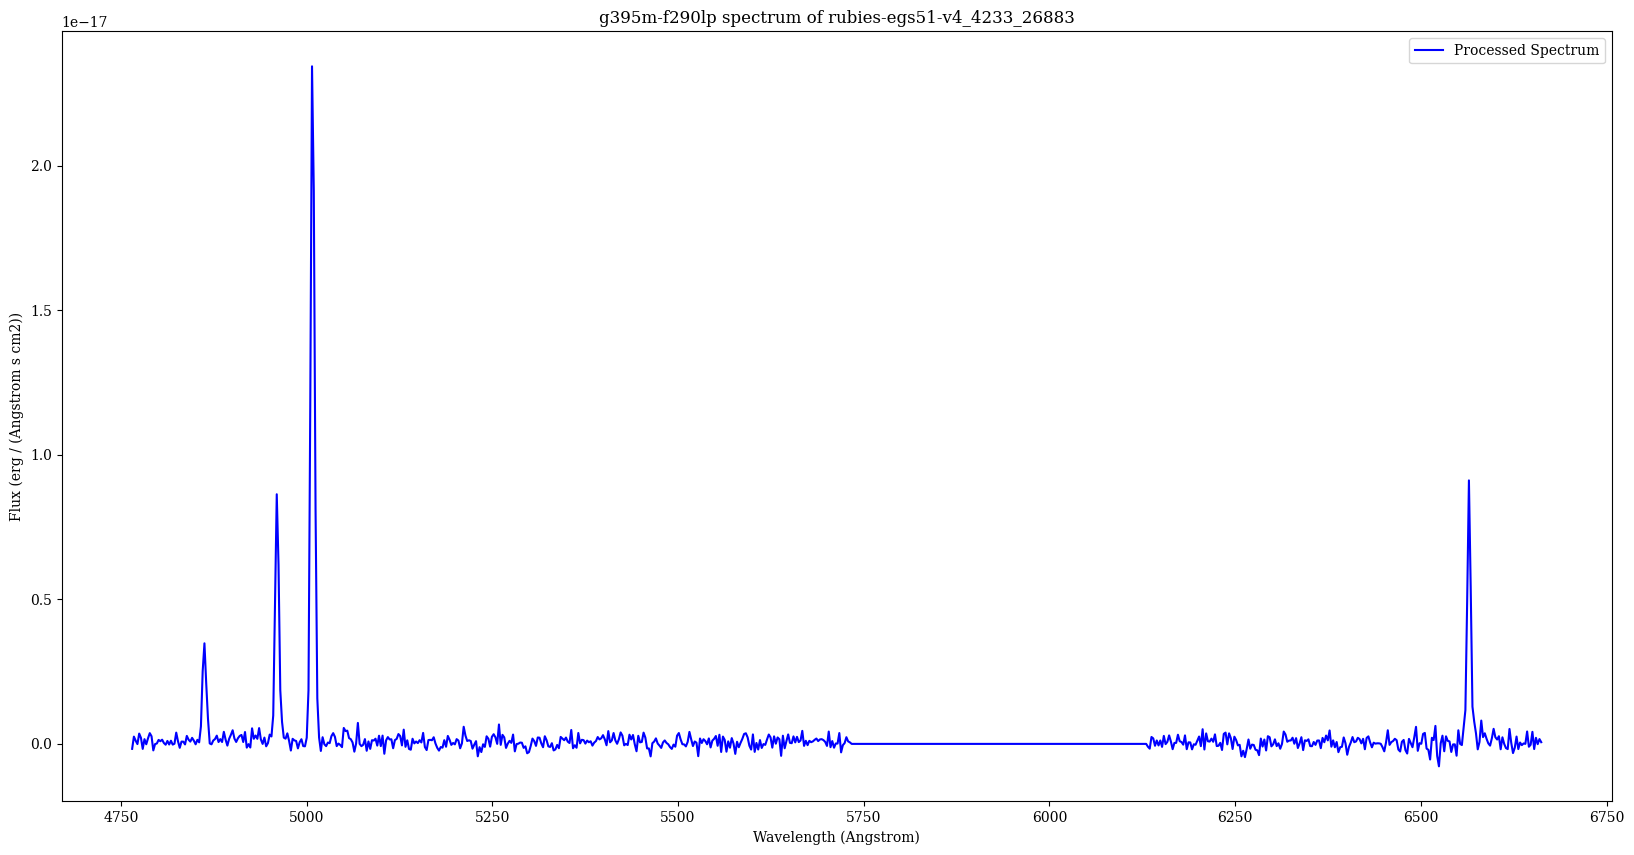

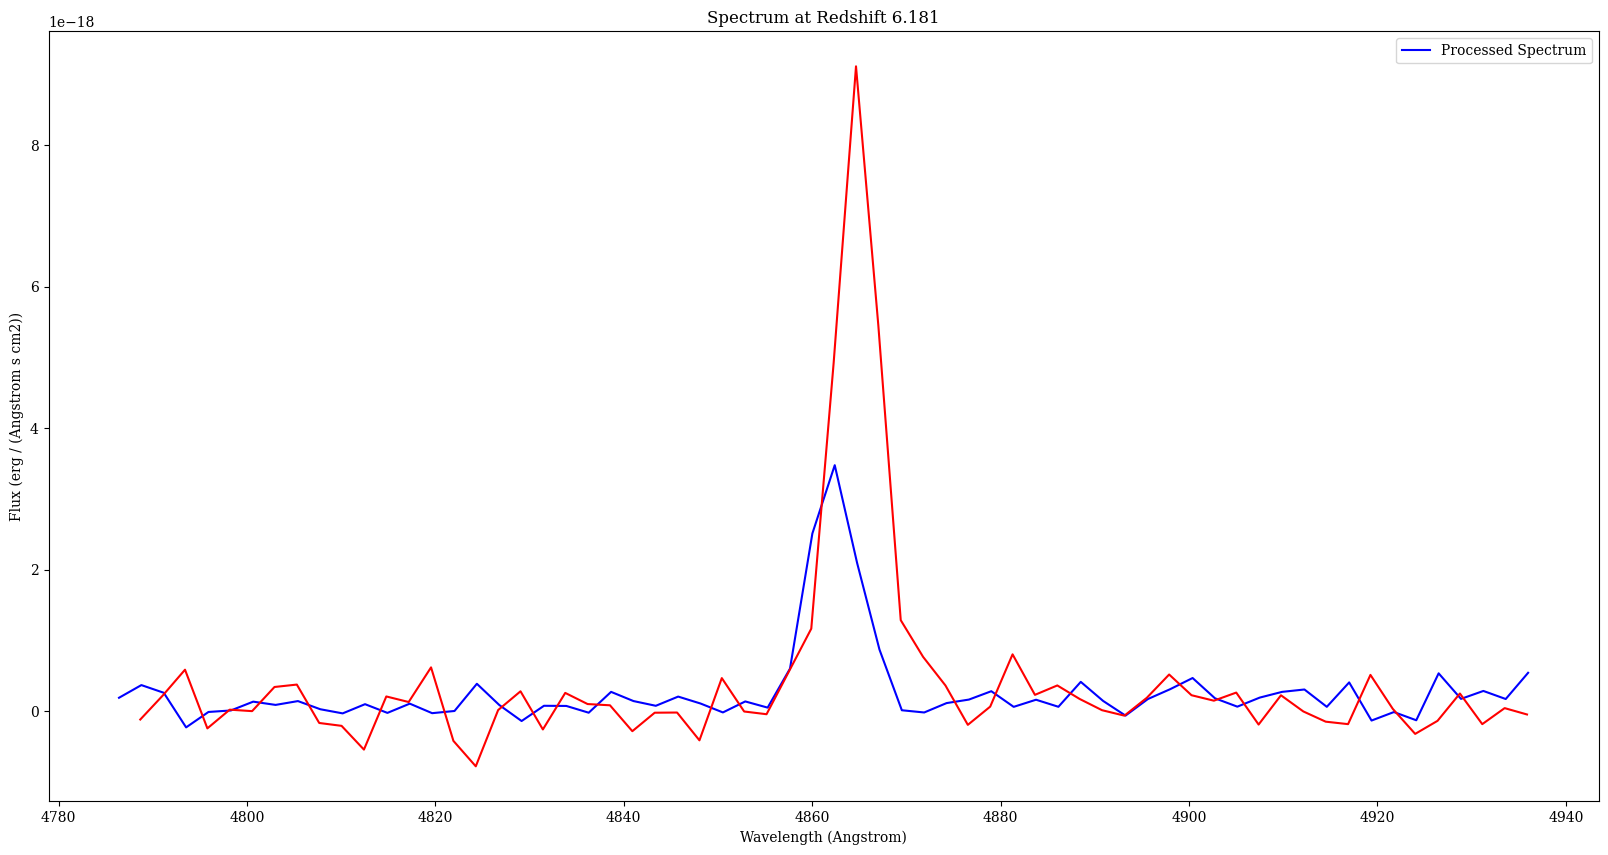

j0910-wang-v4_2028_12784
5.513406716080832e-17
2.238373406260443e-17
2.4631309059786637


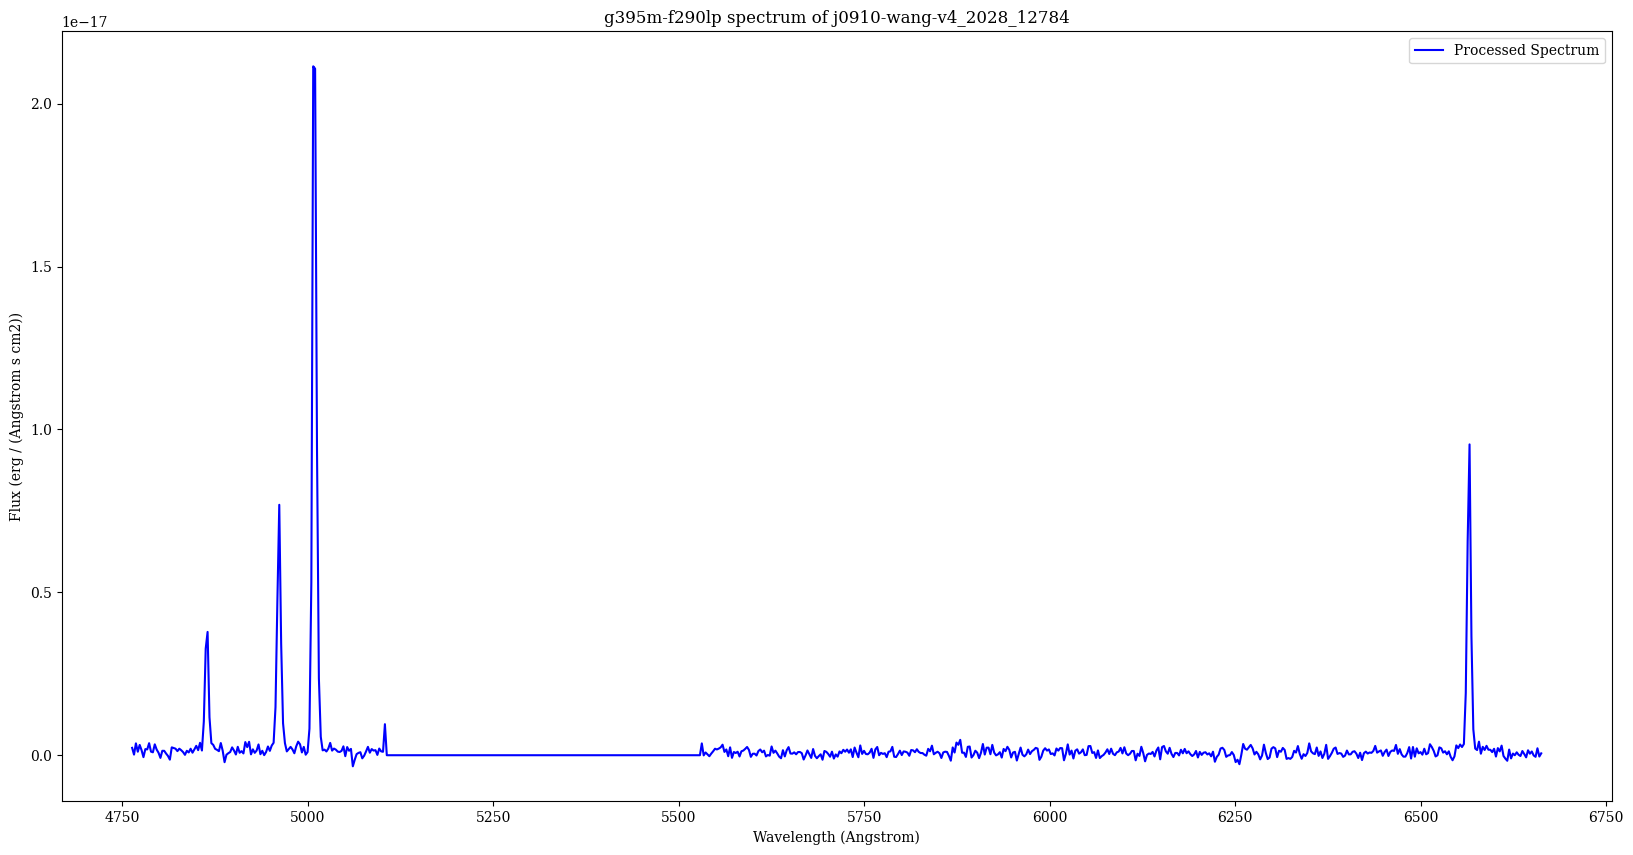

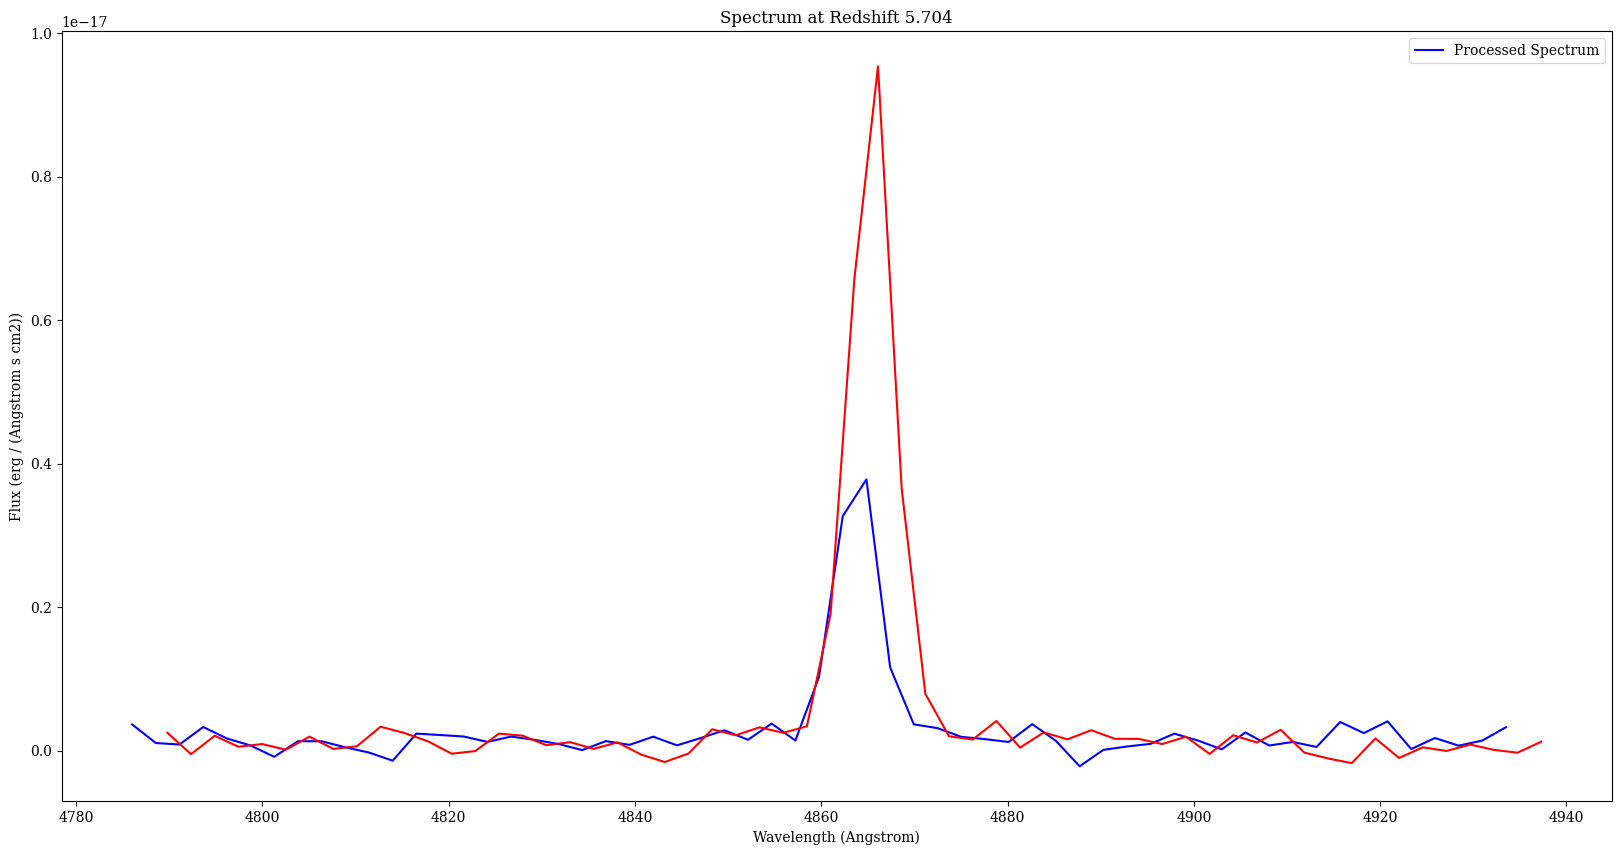

jades-gds-wide3-v4_1180_10013534
1.419279733424404e-17
6.702181388313941e-18
2.1176384988611154


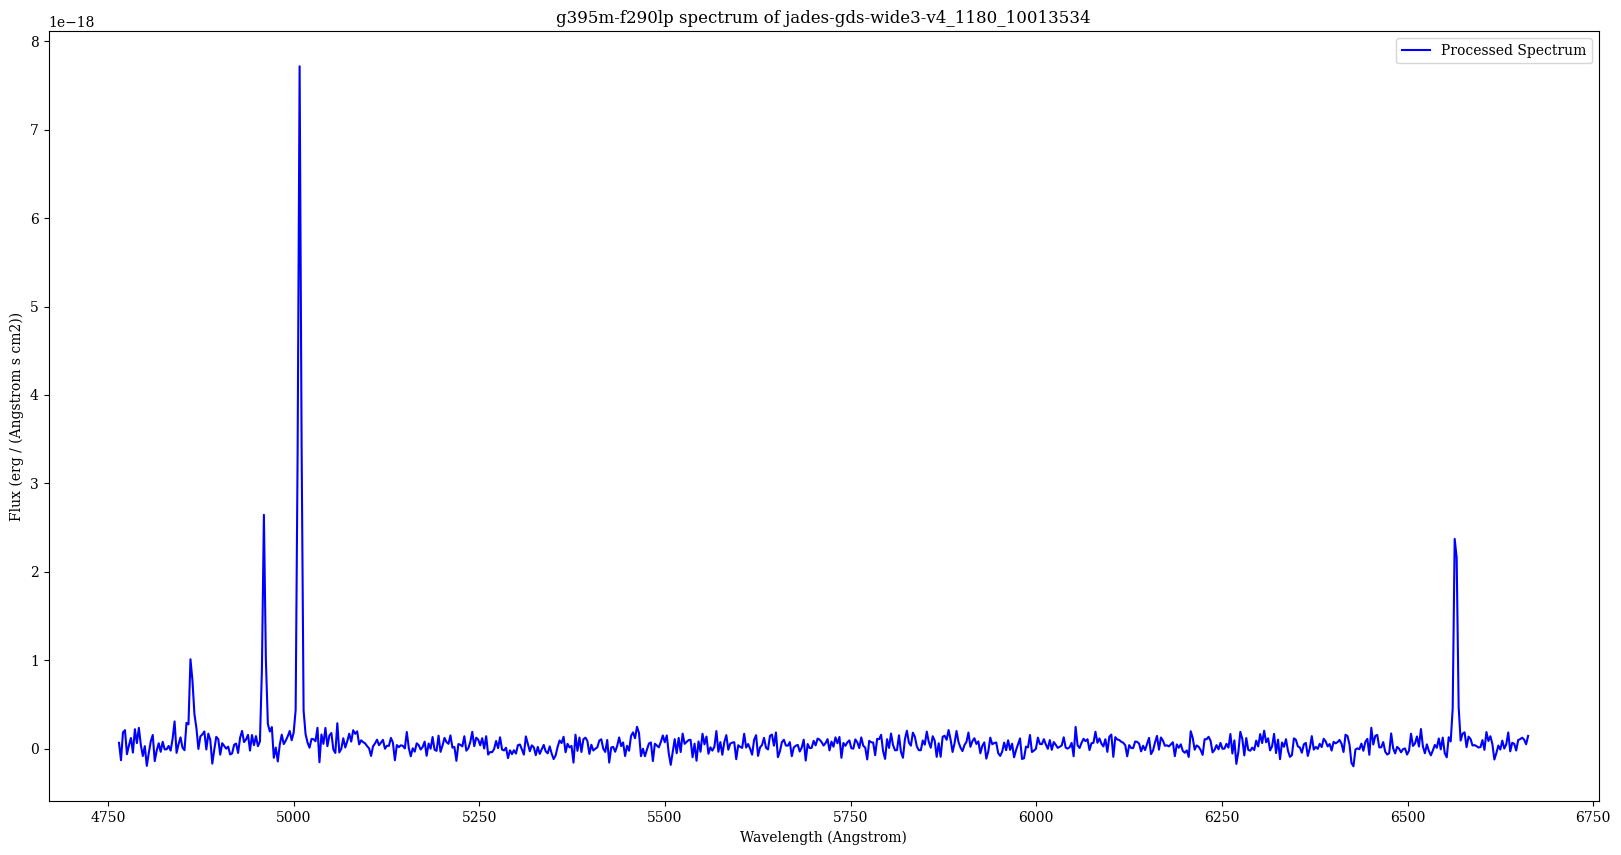

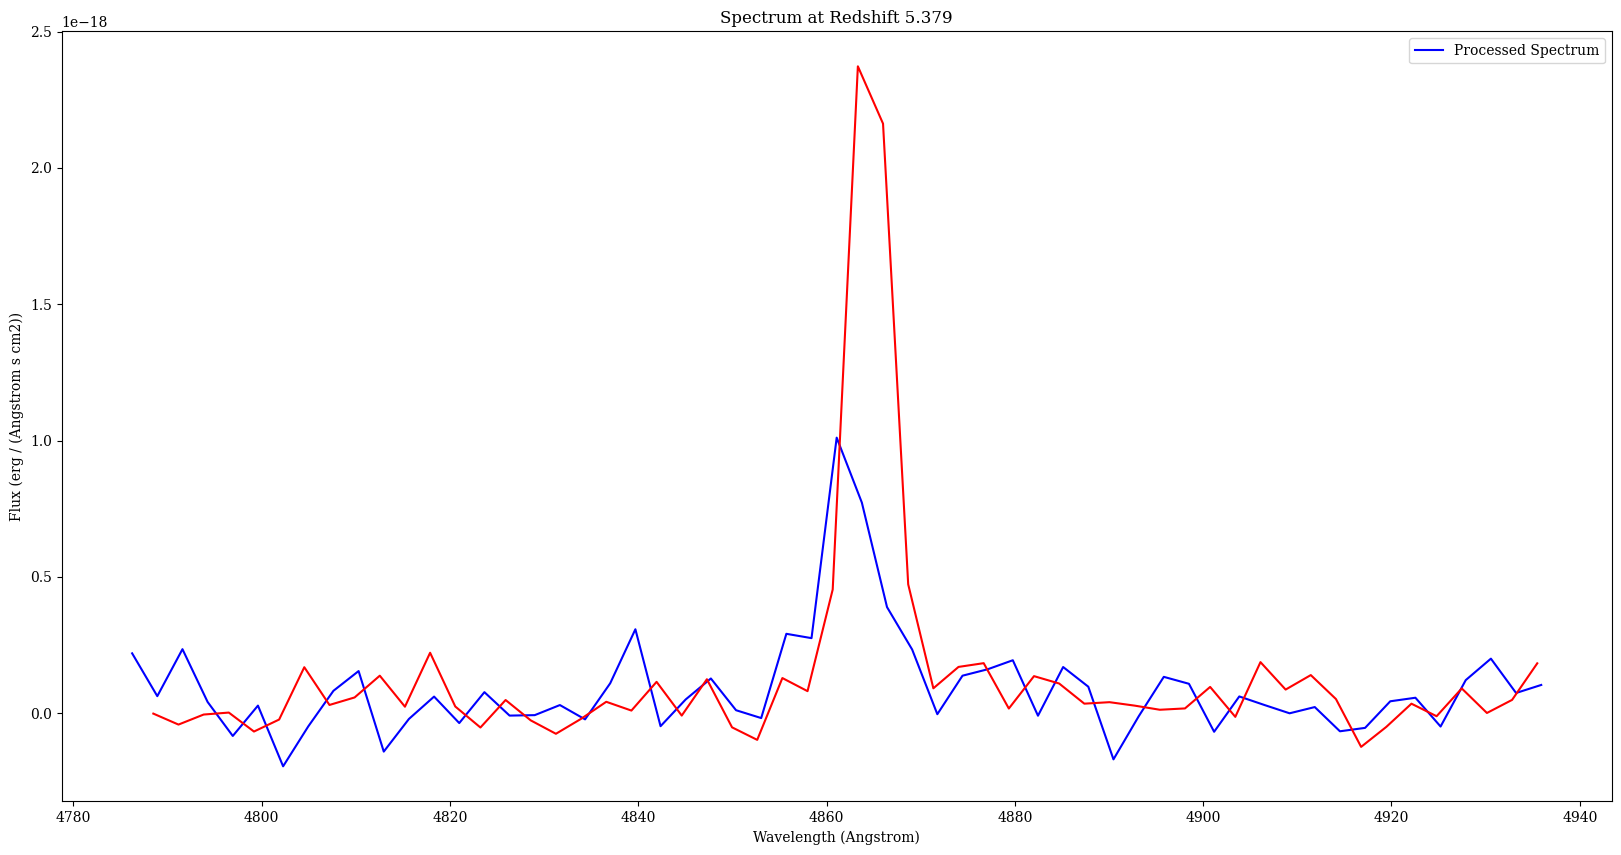

gds-udeep-v4_3215_109389
4.182034268921763e-18
1.7653952008532136e-18
2.3688940962910685


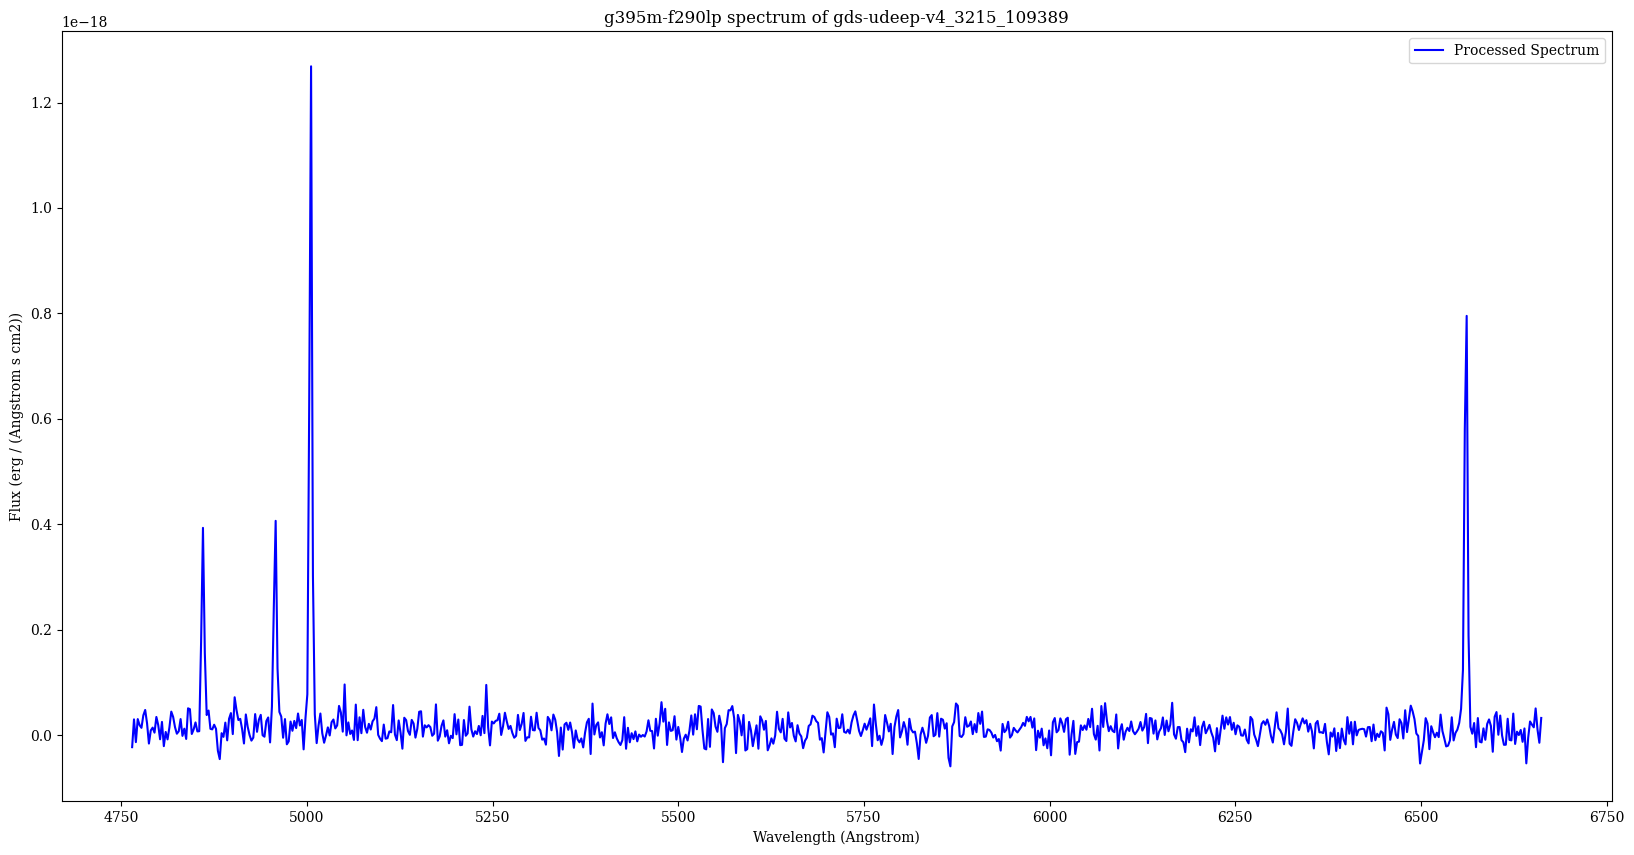

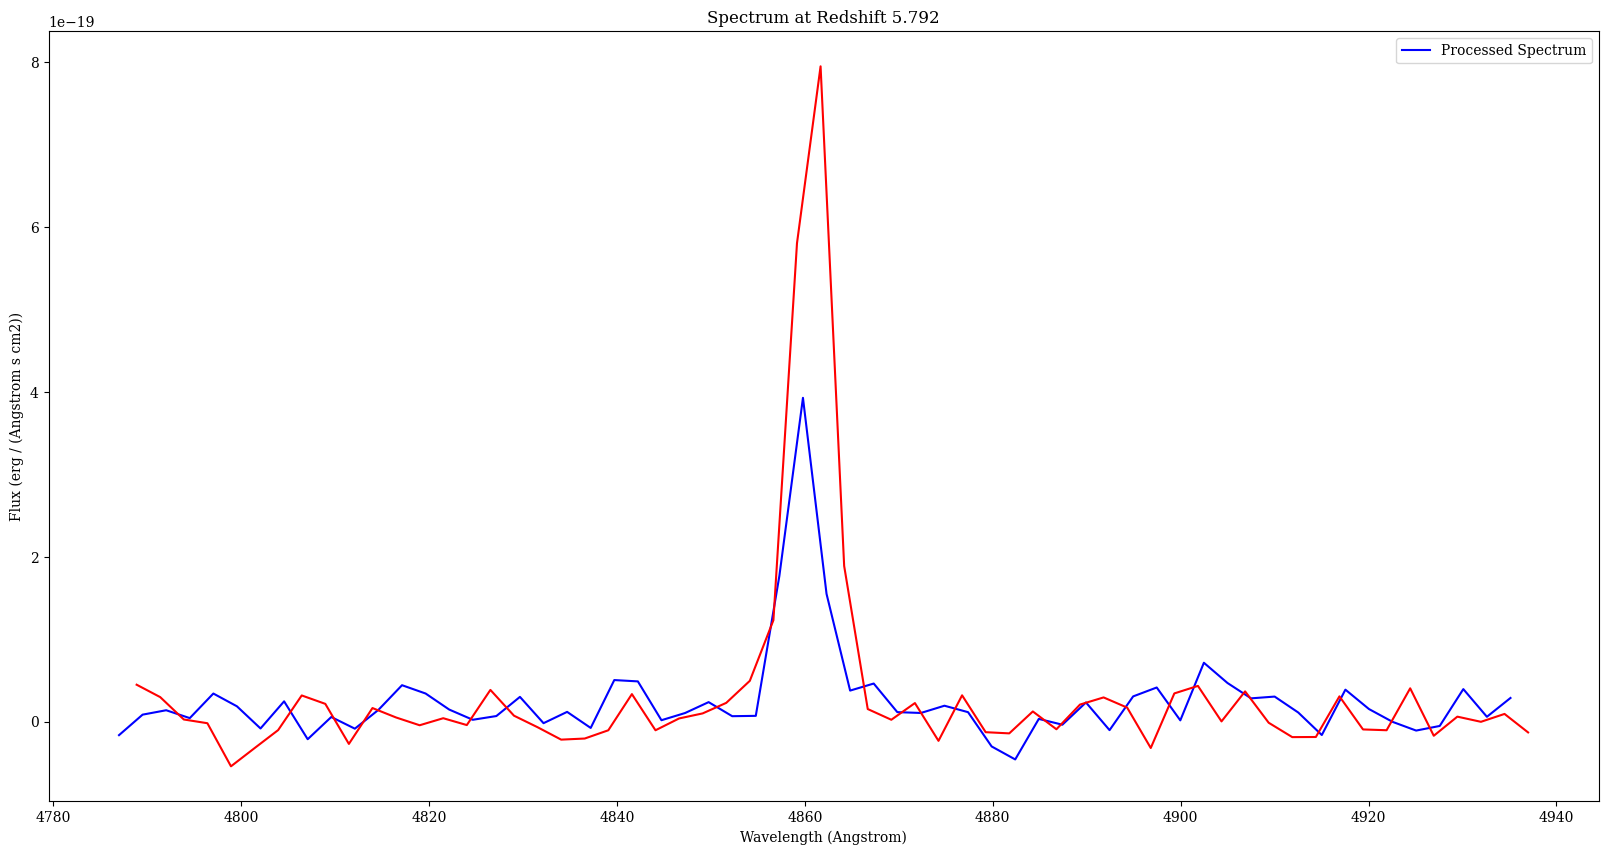

gds-udeep-v4_3215_99671
4.9364347514266116e-18
1.9808553532095552e-18
2.4920722976708864


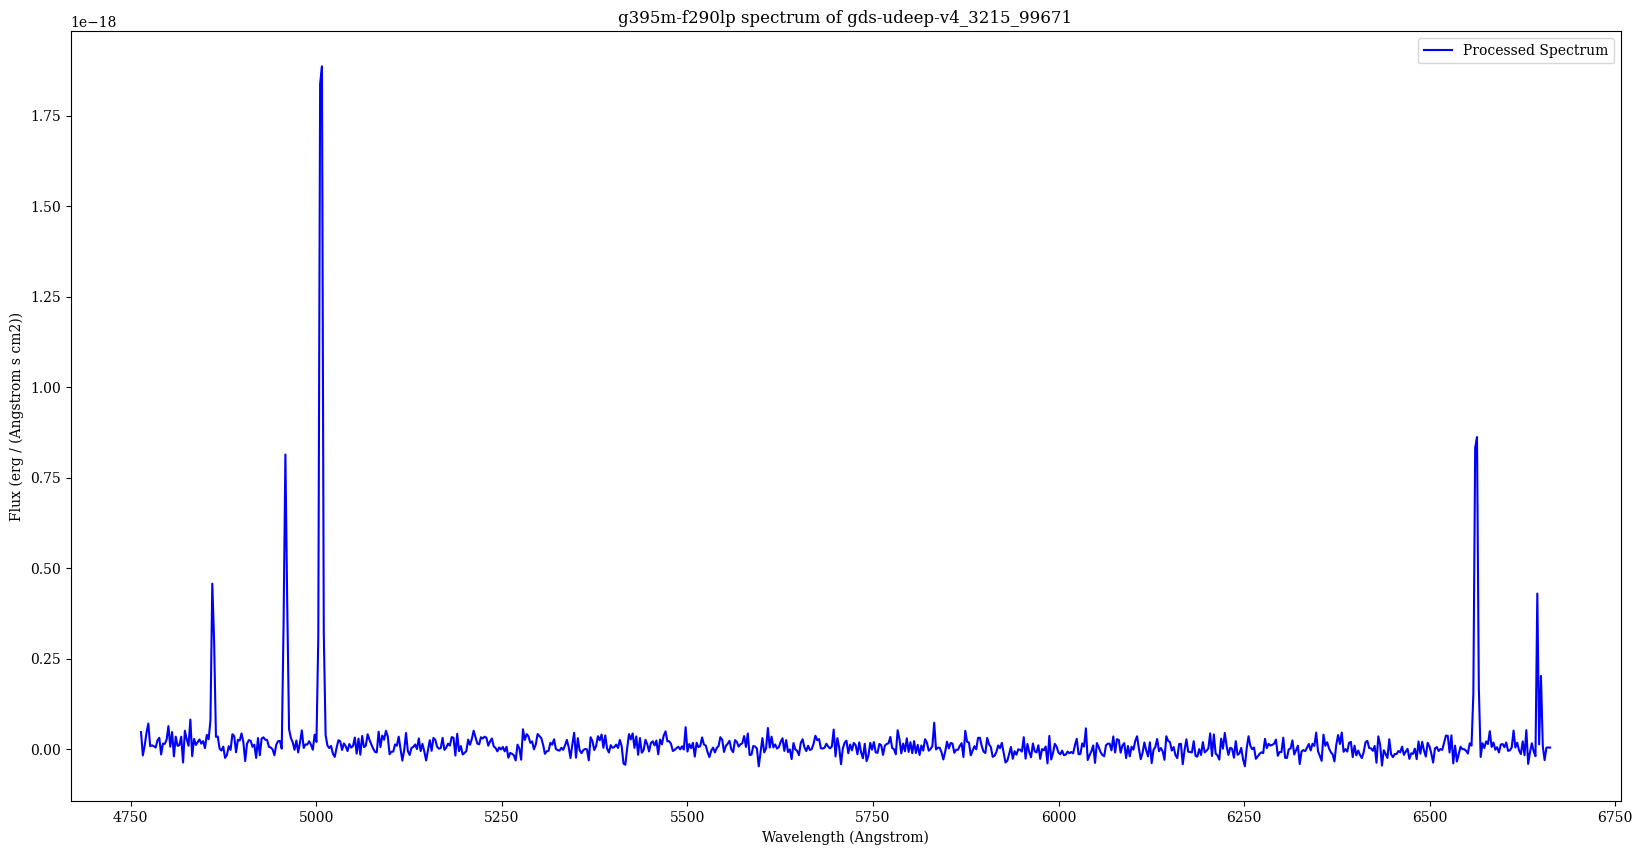

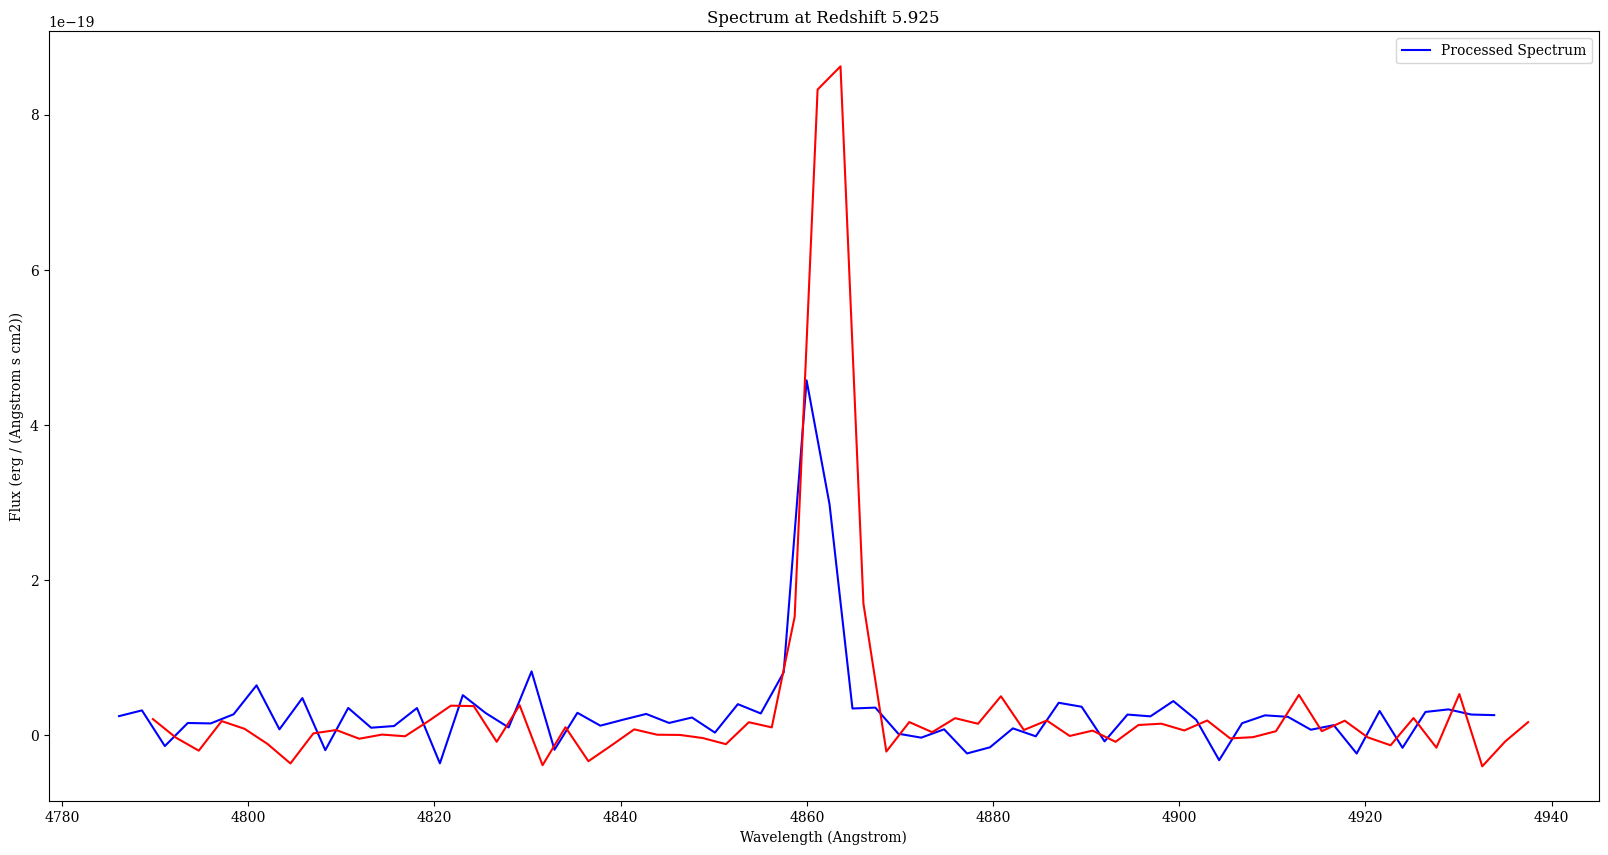

In [25]:
for id, catalog in DJAv4Catalog.catalog_iterator():
    if (catalog['id'] in ids_name):
        try:
            print(catalog['id'])
            for filter, grating_path in catalog['grating_filepaths'].items():
                grating_filepath = os.path.expanduser('~/' + grating_path[16:])
                grating_spectrum=FL.Load_Spectrum_From_Fits(grating_filepath,catalog['determined_redshift'])
                if (grating_spectrum.dual_boundarys()[0]> 4763.0*astropy.units.AA)or(grating_spectrum.dual_boundarys()[1]< 6663.0*astropy.units.AA):
                    continue


                grating_spectrum.set_boundarys(4788.0*astropy.units.AA, 4938.0*astropy.units.AA)
                if 0.0 in np.diff(grating_spectrum.processing_flux.data):
                    continue
                grating_spectrum.set_boundarys(6488.0*astropy.units.AA, 6638.0*astropy.units.AA)
                if 0.0 in np.diff(grating_spectrum.processing_flux.data):
                    continue

                grating_spectrum.reset()

                grating_spectrum.set_boundarys(4763.0*astropy.units.AA, 6663.0*astropy.units.AA)

                fig,ax=grating_spectrum.show(False)
                ax.set_title(f"{filter} spectrum of {catalog['id']}")
                fig.show()


                grating_spectrum.set_boundarys(4763.0*astropy.units.AA, 6663.0*astropy.units.AA)
                alpha_=FL.calculate_err_at_given_wavelength(grating_spectrum, 6563.0*astropy.units.AA)
                print(alpha_[1])
                beta_=FL.calculate_err_at_given_wavelength(grating_spectrum, 4861.0*astropy.units.AA)
                print(beta_[1])
                print(alpha_[1]/beta_[1])
                fig1,ax1=grating_spectrum.show(False)
                grating_spectrum.set_boundarys(6563.0*astropy.units.AA-75.0*astropy.units.AA, 6563.0*astropy.units.AA+75.0*astropy.units.AA)
                ax1.plot(grating_spectrum.processing_wavelengths-1700*astropy.units.AA, grating_spectrum.processing_flux, color='r')


                plt.show()
                break

        except Exception as e:
            print(f"Error processing catalog {id}: {e}")

In [ ]:

count=0
for id, catalog in tqdm(DJAv4Catalog.catalog_iterator()):
    if not catalog['properties']['Sample_Flag']:
        continue

    try:
        for filter, grating_path in catalog['grating_filepaths'].items():
            grating_filepath = os.path.expanduser('~/' + grating_path[16:])
            grating_spectrum=FL.Load_Spectrum_From_Fits(grating_filepath,catalog['determined_redshift'])
            if ((grating_spectrum.dual_boundarys()[0]< 4763.0*astropy.units.AA)&(grating_spectrum.dual_boundarys()[1]> 6663.0*astropy.units.AA)):


                grating_spectrum.set_boundarys(4788.0*astropy.units.AA, 4938.0*astropy.units.AA)
                grating_flux_difference=np.diff(grating_spectrum.processing_flux.data)

                if 0.0 in grating_flux_difference:
                    continue

                grating_spectrum.set_boundarys(6488.0*astropy.units.AA, 6638.0*astropy.units.AA)
                grating_flux_difference=np.diff(grating_spectrum.processing_flux.data)
                if 0.0 in grating_flux_difference:
                    continue


                grating_spectrum.set_boundarys(4763.0*astropy.units.AA, 6663.0*astropy.units.AA)


                fig,ax=grating_spectrum.show(False)
                ax.set_title(f"{filter} spectrum of {catalog['id']}")
                fig.show()
        count+=1
        if count>10:
            break

    except Exception as e:
        print(f"Error processing catalog {id}: {e}")
